In [1]:
!pip install transformers datasets pandas scikit-learn sentencepiece accelerate torch evaluate rouge_score seqeval pandas

  Using cached transformers-4.57.3-py3-none-any.whl.metadata (43 kB)
  Using cached datasets-4.4.1-py3-none-any.whl.metadata (19 kB)
  Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Using cached scikit_learn-1.7.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached sentencepiece-0.2.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (10 kB)
  Using cached accelerate-1.12.0-py3-none-any.whl.metadata (19 kB)
  Using cached torch-2.9.1-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (30 kB)
  Using cached evaluate-0.4.6-py3-none-any.whl.metadata (9.5 kB)
  Using cached rouge_score-0.1.2.tar.gz (17 kB)
  Preparing metadata (setup.py) ... done
  Using cached seqeval-1.2.2.tar.gz (43 kB)
  Preparing metadata (setup.py) ... done
  Using cached filelock-3.20.0-py3-none-any.whl.metadata (2.1 kB)
  Using cached huggingface_hub-0.36.0-py3-none-any.whl.metadata (14 kB)
  Using cached

In [2]:
import pandas as pd
import numpy as np
import torch
import gc
import os
import json
import re
import ast
from collections import defaultdict
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from tqdm import tqdm
import evaluate

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    AutoModelForSequenceClassification,
    AutoModelForTokenClassification,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
    DataCollatorWithPadding,
    DataCollatorForTokenClassification,
    pipeline
)

from seqeval.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import precision_recall_fscore_support, classification_report

In [ ]:
from huggingface_hub import login
login("YOUR_TOKEN")

In [4]:
# ==========================================
# KONFIGURASI
# ==========================================
CSV_FILE_PATH = "final_processed_dataset (1).csv"
BASE_OUTPUT_DIR = "./separated_models"
MARKET_CATEGORIES = ['market', 'stock', 'finance', 'corporate-action', 'business', 'macroeconomy']

In [5]:
def cleanup_memory():
    """Membersihkan VRAM GPU setelah training satu model selesai"""
    torch.cuda.empty_cache()
    gc.collect()

cleanup_memory()

In [6]:
import re
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import DatasetDict, Dataset

def clean_and_normalize_text(text):
    """
    Membersihkan dan menormalisasi text dengan menghilangkan tag, prefix, dan normalisasi lainnya
    """
    if not isinstance(text, str):
        return ""
    
    # 1. Hilangkan prefix yang umum
    prefixes_to_remove = [
        r'^KOMPAS\.com\s*[-–—]\s*',  # KOMPAS.com -, KOMPAS.com –, dll
        r'^JAKARTA,\s*KOMPAS\.com\s*[-–—]\s*',  # JAKARTA, KOMPAS.com -
        r'^DENPASAR,\s*KOMPAS\.com\s*[-–—]\s*',  # DENPASAR, KOMPAS.com -
        r'^BANDUNG,\s*KOMPAS\.com\s*[-–—]\s*',   # BANDUNG, KOMPAS.com -
        r'^SURABAYA,\s*KOMPAS\.com\s*[-–—]\s*',  # SURABAYA, KOMPAS.com -
        r'^YOGYAKARTA,\s*KOMPAS\.com\s*[-–—]\s*', # YOGYAKARTA, KOMPAS.com -
        r'^MEDAN,\s*KOMPAS\.com\s*[-–—]\s*',     # MEDAN, KOMPAS.com -
        r'^MAKASSAR,\s*KOMPAS\.com\s*[-–—]\s*',  # MAKASSAR, KOMPAS.com -
        r'^SEMARANG,\s*KOMPAS\.com\s*[-–—]\s*',  # SEMARANG, KOMPAS.com -
        r'^PALEMBANG,\s*KOMPAS\.com\s*[-–—]\s*', # PALEMBANG, KOMPAS.com -
        r'^BALIKPAPAN,\s*KOMPAS\.com\s*[-–—]\s*', # BALIKPAPAN, KOMPAS.com -
        r'^BANJARMASIN,\s*KOMPAS\.com\s*[-–—]\s*', # BANJARMASIN, KOMPAS.com -
        r'^MANADO,\s*KOMPAS\.com\s*[-–—]\s*',    # MANADO, KOMPAS.com -
        r'^JAYAPURA,\s*KOMPAS\.com\s*[-–—]\s*',  # JAYAPURA, KOMPAS.com -
        r'^MATARAM,\s*KOMPAS\.com\s*[-–—]\s*',   # MATARAM, KOMPAS.com -
        r'^KUPANG,\s*KOMPAS\.com\s*[-–—]\s*',    # KUPANG, KOMPAS.com -
        r'^PADANG,\s*KOMPAS\.com\s*[-–—]\s*',    # PADANG, KOMPAS.com -
        r'^PONTIANAK,\s*KOMPAS\.com\s*[-–—]\s*', # PONTIANAK, KOMPAS.com -
        r'^BANDA ACEH,\s*KOMPAS\.com\s*[-–—]\s*', # BANDA ACEH, KOMPAS.com -
        r'^PALU,\s*KOMPAS\.com\s*[-–—]\s*',      # PALU, KOMPAS.com -
        r'^AMBON,\s*KOMPAS\.com\s*[-–—]\s*',     # AMBON, KOMPAS.com -
        r'^TERNATE,\s*KOMPAS\.com\s*[-–—]\s*',   # TERNATE, KOMPAS.com -
        r'^SORONG,\s*KOMPAS\.com\s*[-–—]\s*',    # SORONG, KOMPAS.com -
        r'^KENDARI,\s*KOMPAS\.com\s*[-–—]\s*',   # KENDARI, KOMPAS.com -
        r'^GORONTALO,\s*KOMPAS\.com\s*[-–—]\s*', # GORONTALO, KOMPAS.com -
        r'^MAMUJU,\s*KOMPAS\.com\s*[-–—]\s*',    # MAMUJU, KOMPAS.com -
        r'^TANJUNGSELOR,\s*KOMPAS\.com\s*[-–—]\s*', # TANJUNGSELOR, KOMPAS.com -
        r'^MERAUKE,\s*KOMPAS\.com\s*[-–—]\s*',   # MERAUKE, KOMPAS.com -
    ]
    
    cleaned_text = text
    for pattern in prefixes_to_remove:
        cleaned_text = re.sub(pattern, '', cleaned_text, flags=re.IGNORECASE)
    
    # 2. Hilangkan tag HTML sederhana
    cleaned_text = re.sub(r'<[^>]+>', '', cleaned_text)
    
    # 3. Normalisasi whitespace
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text)  # Ganti multiple spaces dengan single space
    cleaned_text = cleaned_text.strip()
    
    # 4. Normalisasi dash dan hyphen
    cleaned_text = re.sub(r'[–—]', '-', cleaned_text)
    
    # 5. Hilangkan karakter khusus yang tidak perlu di awal text
    cleaned_text = re.sub(r'^[^\w\s]+', '', cleaned_text)
    
    # 6. Normalisasi quotes
    cleaned_text = re.sub(r'[`´]', "'", cleaned_text)
    cleaned_text = re.sub(r'[«»""]', '"', cleaned_text)
    
    # 7. Hilangkan bullet points dan numbering di awal
    cleaned_text = re.sub(r'^[\s•·▪➢➤›-]*\d+[\.\)]\s*', '', cleaned_text)
    cleaned_text = re.sub(r'^[\s•·▪➢➤›-]+\s*', '', cleaned_text)
    
    # 8. Normalisasi ellipsis
    cleaned_text = re.sub(r'\.{3,}', '...', cleaned_text)
    
    # 9. Hilangkan extra spaces setelah normalisasi
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
    
    return cleaned_text

def apply_category_mapping(df):
    """
    Apply category mapping ke dataframe
    """
    df_mapped = df.copy()
    df_mapped["category_mapped"] = df_mapped["category"].apply(map_category)
    return df_mapped

def preprocess_dataframe(df, apply_text_cleaning=True, apply_category_mapping_flag=True):
    """
    Preprocess lengkap untuk dataframe
    """
    print("Memulai preprocessing data...")
    
    # 1. Hilangkan rows dengan data kosong
    initial_count = len(df)
    df = df.dropna(subset=['body_text', 'category', 'ner', 'summary'])
    after_dropna_count = len(df)
    print(f"  - Drop NA: {initial_count} → {after_dropna_count} rows")
    
    # 2. Filter text yang terlalu pendek
    df = df[df['body_text'].str.len() > 20]
    after_length_filter = len(df)
    print(f"  - Filter length >20: {after_dropna_count} → {after_length_filter} rows")
    
    # 3. Cleaning text
    if apply_text_cleaning:
        print("  - Membersihkan dan menormalisasi text...")
        df_cleaned = df.copy()
        df_cleaned['body_text_original'] = df_cleaned['body_text']  # Simpan original
        df_cleaned['body_text'] = df_cleaned['body_text'].apply(clean_and_normalize_text)
        
        # Hitung perubahan
        changed_count = (df_cleaned['body_text_original'] != df_cleaned['body_text']).sum()
        print(f"    {changed_count}/{len(df_cleaned)} texts berubah setelah cleaning")
        
        # Filter lagi yang menjadi terlalu pendek setelah cleaning
        before_clean_filter = len(df_cleaned)
        df_cleaned = df_cleaned[df_cleaned['body_text'].str.len() > 10]
        after_clean_filter = len(df_cleaned)
        print(f"    Filter setelah cleaning: {before_clean_filter} → {after_clean_filter} rows")
        
        df = df_cleaned
    
    # 4. Apply category mapping
    if apply_category_mapping_flag:
        print("  - Menerapkan category mapping...")
        df = apply_category_mapping(df)
        
        # Tampilkan distribusi kategori
        category_dist = df['category_mapped'].value_counts()
        print(f"    Distribusi kategori setelah mapping:")
        for cat, count in category_dist.head(10).items():  # Tampilkan 10 teratas
            print(f"      {cat}: {count} samples")
        if len(category_dist) > 10:
            print(f"      ... dan {len(category_dist) - 10} kategori lainnya")
    
    print(f"✅ Preprocessing selesai. Total data: {len(df)} rows")
    return df

# Load Dataset dengan preprocessing
print("Loading Dataset dengan preprocessing...")
df_raw = pd.read_csv(CSV_FILE_PATH)

# Preprocess data
df_processed = preprocess_dataframe(
    df_raw, 
    apply_text_cleaning=True, 
    apply_category_mapping_flag=False
)

# Split data
train_val_df, test_df = train_test_split(df_processed, test_size=0.1, random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.1, random_state=42)

print(f"\nJumlah Data setelah preprocessing:")
print(f"  Train : {len(train_df)} baris")
print(f"  Val   : {len(val_df)} baris") 
print(f"  Test  : {len(test_df)} baris")

# Buat datasets
raw_datasets = DatasetDict({
    'train': Dataset.from_pandas(train_df.reset_index(drop=True)),
    'validation': Dataset.from_pandas(val_df.reset_index(drop=True)),
    'test': Dataset.from_pandas(test_df.reset_index(drop=True))
})

# Tampilkan contoh sebelum dan sesudah cleaning
print("\n📋 CONTOH SEBELUM DAN SESUDAH CLEANING:")
print("=" * 80)
sample_idx = 0
if 'body_text_original' in train_df.columns:
    original = train_df.iloc[sample_idx]['body_text_original']
    cleaned = train_df.iloc[sample_idx]['body_text']
    
    print("SEBELUM:")
    print(f"  Text: {original[:200]}...")
    print("\nSESUDAH:")
    print(f"  Text: {cleaned[:200]}...")
    print("=" * 80)

Loading Dataset dengan preprocessing...
Memulai preprocessing data...
  - Drop NA: 3116 → 3116 rows
  - Filter length >20: 3116 → 3116 rows
  - Membersihkan dan menormalisasi text...
    3094/3116 texts berubah setelah cleaning
    Filter setelah cleaning: 3116 → 3116 rows
✅ Preprocessing selesai. Total data: 3116 rows

Jumlah Data setelah preprocessing:
  Train : 2523 baris
  Val   : 281 baris
  Test  : 312 baris

📋 CONTOH SEBELUM DAN SESUDAH CLEANING:
SEBELUM:
  Text: KOMPAS.com -Pelatih tim nasional Italia, Gennaro Gattuso, angkat bicara usai hasil drawing playoff Piala Dunia 2026 Zona Eropa mempertemukan timnya dengan Irlandia Utara.

Drawing playoffPiala Dunia 2...

SESUDAH:
  Text: Pelatih tim nasional Italia, Gennaro Gattuso, angkat bicara usai hasil drawing playoff Piala Dunia 2026 Zona Eropa mempertemukan timnya dengan Irlandia Utara. Drawing playoffPiala Dunia 2026Zona Eropa...


In [7]:
train_df.tail(10)

,author,body_text,category,channel,error,link,published_date,scraped_at,title,ner,summary,body_text_original
1104,Tim Cek Fakta,"Berdasarkan verifikasi Kompas.com sejauh ini, ...",news,cek_fakta,NaN,https://www.kompas.com/cekfakta/read/2025/11/2...,"Kompas.com, 22 November 2025, 10:01 WIB",2025-11-22T16:55:31.011783,[KLARIFIKASI] Video Ini Bukan Pengerahan Kapal...,"[{'entity': 'Kompas.com', 'type': 'ORG'}, {'en...",Video yang beredar mengenai kapal perang China...,"Berdasarkan verifikasi Kompas.com sejauh ini, ..."
1036,NaN,Penjabat (Pj) Gubernur Provinsi Sulawesi Selat...,news,kilas_daerah,NaN,https://kilasdaerah.kompas.com/sulsel/read/202...,"Kompas.com- 26/05/2024, 13:02 WIB",2025-11-22T16:55:28.875523,"Budayakan Hidup Sehat, Pj Gubernur Sulsel Ajak...","[{'entity': 'Zudan Arif Fakrulloh', 'type': 'P...",Pj Gubernur Sulsel Zudan Arif Fakrulloh ajak O...,KOMPAS.com– Penjabat (Pj) Gubernur Provinsi Su...
421,NaN,Pani Gold Project(PGP) atau Proyek Emas Pani a...,news,kilas_korporasi,NaN,https://kilaskorporasi.kompas.com/bakti-merdek...,"Kompas.com- 23/12/2024, 16:03 WIB",2025-11-22T16:54:57.229858,"Pani Gold Project, Proyek Masa Depan MDKA yang...","[{'entity': 'Pani Gold Project', 'type': 'ORG'...","Pani Gold Project di Gorontalo, milik PT Merde...",KOMPAS.com-Pani Gold Project(PGP) atau Proyek ...
220,Sakina Rakhma Diah Setiawan,"PT Bukit Makmur Mandiri Utama (BUMA), anak usa...",finance,energi,NaN,https://money.kompas.com/read/2025/11/19/14561...,"Kompas.com, 19 November 2025, 14:56 WIB",2025-11-22T16:54:45.558127,"Anak Usaha DOID Lunasi Senior Notes 2026 212,2...","[{'entity': 'JAKARTA', 'type': 'GPE'}, {'entit...",BUMA melunasi lebih awal Senior Notes 2026 sen...,"JAKARTA, KOMPAS.com —PT Bukit Makmur Mandiri U..."
2980,Adhi Prasetya -Sport,Menteri Pemuda dan Olahraga Erick Thohir memas...,sport-lain,sport,NaN,https://sport.detik.com/sport-lain/d-8222781/s...,"Jumat, 21 Nov 2025 23:15 WIB",2025-11-22T13:04:37.750168,SEA Games 2025: CdM Optimis Indonesia Penuhi T...,"[{'entity': 'Erick Thohir', 'type': 'PER'}, {'...",Indonesia menargetkan 80 emas di SEA Games 202...,Menteri Pemuda dan Olahraga Erick Thohir memas...
2292,"Aisyah Sekar Ayu Maharani,",Sertifikat tanah yang hilang diimbau untuk seg...,properti,tips_properti,NaN,https://properti.kompas.com/read/2025/11/22/13...,"Kompas.com- 22 November 2025, 13:00 WIB",2025-11-22T16:55:54.917453,Berapa Biaya Urus Sertifikat Tanah yang Hilang?,"[{'entity': 'JAKARTA', 'type': 'GPE'}, {'entit...",Masyarakat yang kehilangan sertifikat tanah di...,"JAKARTA, KOMPAS.com- Sertifikat tanah yang hil..."
1259,"Suhaiela Bahfein,",Bank Indonesia (BI) mengungkap alasan penerima...,properti,properti,NaN,https://www.kompas.com/properti/read/2025/11/2...,"Kompas.com, 20 November 2025, 23:00 WIB",2025-11-22T16:55:39.777970,"Ini Alasan BI Terima REPO SMF, Jadi Sejarah Baru","[{'entity': 'Bank Indonesia', 'type': 'ORG'}, ...",BI menerima corporate bond SMF sebagai underly...,"JAKARTA, KOMPAS.com- Bank Indonesia (BI) mengu..."
2462,Anisa Indraini -detikFinance,Menteri Keuangan Purbaya Yudhi Sadewa buka sua...,finance,berita-ekonomi-bisnis,NaN,https://finance.detik.com/berita-ekonomi-bisni...,"Sabtu, 22 Nov 2025 12:45 WIB",2025-11-22T12:50:42.875305,Purbaya Ungkap Anak Buahnya Dipanggil Kejagung...,"[{'entity': 'Purbaya Yudhi Sadewa', 'type': 'P...",Menkeu Purbaya menyebut pencekalan mantan Dirj...,Menteri Keuangan Purbaya Yudhi Sadewa buka sua...
2806,Andi Hidayat -detikFinance,Kementerian Keuangan (Kemenkeu) menyebut Indon...,finance,bursa-dan-valas,NaN,https://finance.detik.com/bursa-dan-valas/d-82...,"Senin, 17 Nov 2025 18:30 WIB",2025-11-22T12:59:54.882625,"RI Surplus 1 Miliar Ton Karbon Kredit, Kemenke...","[{'entity': 'Kementerian Keuangan', 'type': 'O...",Indonesia dinilai lebih progresif dalam meneka...,Kementerian Keuangan (Kemenkeu) menyebut Indon...
2714,Hana Nushratu -detikFinance,Dompet digital DANA menghadirkan fitur jaminan...,finance,fintech,NaN,https://finance.detik.com/fintech/d-8

In [8]:
# ENTITY TYPE MAPPING CONFIGURATION
ENTITY_TYPE_MAPPING = {
    # Mapping dari entity types di data ke standard types
    "AGE": "QTY",      # Age -> Quantity
    "BEA": "PRD",      # Beast -> Product  
    "COL": "ORG",      # College -> Organization
    "CULT": "REG",     # Culture -> Religion
    "CUR": "MON",      # Currency -> Money
    "DAY": "DAT",      # Day -> Date
    "HOT": "FAC",      # Hotel -> Facility
    "LA": "LAW",       # Law -> Law Entity
    "LAN": "LAN",      # Language -> Language (same)
    "LAW": "LAW",      # Law -> Law Entity (same)
    "LEAGUE": "ORG",   # League -> Organization
    "NOR": "ORG",      # Political Organization -> Organization
    "ORD": "ORD",      # Ordinal -> Ordinal (same)
    "ORF": "ORG",      # Organization Formal -> Organization
    "ORG": "ORG",      # Organization -> Organization (same)
    "PER": "PER",      # Person -> Person (same)
    "PLAN": "EVT",     # Plan -> Event
    "POL": "ORG",      # Political -> Organization
    "POR": "ORG",      # Portfolio -> Organization
    "PRC": "PRC",      # Percent -> Percent (same)
    "PRD": "PRD",      # Product -> Product (same)
    "PRO": "ORG",      # Professional -> Organization
    "PROC": "EVT",     # Process -> Event
    "PROD": "PRD",     # Product -> Product (same)
    "QTY": "QTY",      # Quantity -> Quantity (same)
    "RAT": "PRC",      # Rate -> Percent
    "REG": "REG",      # Region -> Geopolitical Entity
    "REL": "REG",      # Religion -> Religion
    "TECH": "PRD",     # Technology -> Product
    "TIM": "TIM",      # Time -> Time (same)
    "URL": "WEB",      # URL -> Web
    "WAA": "WOA",      # Work of Art -> Work of Art
    "WAO": "WOA",      # Work of Art -> Work of Art
    "WEB": "WEB",      # Web -> Web (same)
    "WGA": "WOA",      # Work of Art -> Work of Art
    "WOA": "WOA",      # Work of Art -> Work of Art (same)
    "WOK": "WOA",      # Work of Art -> Work of Art
    "WOP": "WOA",      # Work of Art -> Work of Art
    "WP": "WOA",       # Work of Art -> Work of Art
    "WPA": "WOA",      # Work of Art -> Work of Art
    "WQA": "WOA",      # Work of Art -> Work of Art
    
    # Standard types dari prompt
    "CRD": "CRD",
    "DAT": "DAT", 
    "EVT": "EVT",
    "FAC": "FAC",
    "GPE": "GPE",
    "LOC": "LOC",
    "MON": "MON",
}

# Target entity types sesuai prompt
TARGET_ENTITY_TYPES = {
    "CRD", "DAT", "EVT", "FAC", "GPE", "LAW", "LOC", "MON", 
    "NOR", "ORD", "ORG", "PER", "PRC", "PRD", "QTY", "REG", 
    "TIM", "WOA", "LAN"
}

def map_entity_type(entity_type):
    """Map entity type ke standard type"""
    mapped = ENTITY_TYPE_MAPPING.get(entity_type, entity_type)
    if mapped not in TARGET_ENTITY_TYPES:
        return "ORG"
    return mapped

def norm_type(t):
    """Normalize type dengan mapping"""
    original_norm = t.upper().replace(" ", "_").replace("/", "_")
    return map_entity_type(original_norm)

# TRAIN NER MODEL
NER_MODEL_CANDIDATES = [
    "cahya/NusaBert-ner-v1.3"
]

def parse_ner_field(raw):
    if raw is None:
        return []
    if isinstance(raw, list):
        return raw
    if isinstance(raw, dict):
        return [raw]
    if isinstance(raw, str):
        s = raw.strip()
        if not s:
            return []
        try:
            return json.loads(s)
        except json.JSONDecodeError:
            pass
        try:
            obj = ast.literal_eval(s)
            if isinstance(obj, list):
                return obj
            if isinstance(obj, dict):
                return [obj]
            return []
        except Exception:
            return []
    return []

def extract_entity_types(example):
    ents = parse_ner_field(example["ner"])
    types = [e.get("type", "") for e in ents if "type" in e]
    return {"ent_types": types}

def train_ner_model(model_name, raw_datasets, base_output_dir, max_length=512, batch_size=16, epochs=5):
    print(f"Training NER model: {model_name}")
    print("=" * 50)
    
    try:
        tmp = raw_datasets.map(extract_entity_types)
        
        all_types = set()
        for split in ["train", "validation"]:
            for ts in tmp[split]["ent_types"]:
                all_types.update(ts)
        
        normalized_types = {norm_type(t) for t in all_types if t}
        
        filtered_types = {t for t in normalized_types if t in TARGET_ENTITY_TYPES}
        
        print(f"Original entity types: {len(all_types)}")
        print(f"After normalization: {len(normalized_types)}")
        print(f"After filtering to target types: {len(filtered_types)}")
        
        final_types = filtered_types if filtered_types else normalized_types
        
        label_list = sorted(
            {f"B-{t}" for t in final_types}
            | {f"I-{t}" for t in final_types}
            | {"O"}
        )
        label_to_id = {l: i for i, l in enumerate(label_list)}
        id_to_label = {i: l for l, i in label_to_id.items()}
        
        print(f"Final entity types: {len(final_types)}")
        print(f"Total labels: {len(label_list)}")
        print(f"Labels: {sorted(final_types)}")
        
        tokenizer_ner = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        
        model_ner = AutoModelForTokenClassification.from_pretrained(
            model_name,
            num_labels=len(label_list),
            id2label=id_to_label,
            label2id=label_to_id,
            ignore_mismatched_sizes=True
        )
        
        def find_entity_spans(text, entities):
            spans = []
            for ent in entities:
                ent_text = (ent.get("entity") or "").strip()
                ent_type_raw = ent.get("type")
                if not ent_text or not ent_type_raw:
                    continue

                # Gunakan mapped entity type
                ent_type = norm_type(ent_type_raw)
                pattern = re.escape(ent_text)
                for m in re.finditer(pattern, text):
                    start, end = m.start(), m.end()
                    spans.append((start, end, ent_type))
            return spans

        def preprocess_ner(examples):
            texts = examples["body_text"]
            ner_raw_list = examples["ner"]

            encodings = tokenizer_ner(
                texts,
                truncation=True,
                padding="max_length",
                max_length=max_length,
                return_offsets_mapping=True,
            )

            all_labels = []

            for i, text in enumerate(texts):
                ents = parse_ner_field(ner_raw_list[i])
                spans = find_entity_spans(text, ents)
                offsets = encodings["offset_mapping"][i]
                labels = ["O"] * len(offsets)

                for (start_char, end_char, ent_type) in spans:
                    for tok_idx, (tok_start, tok_end) in enumerate(offsets):
                        if tok_start == tok_end:
                            continue
                        if tok_end <= start_char or tok_start >= end_char:
                            continue

                        if labels[tok_idx] == "O":
                            labels[tok_idx] = f"B-{ent_type}"
                        else:
                            labels[tok_idx] = f"I-{ent_type}"

                label_ids = []
                for (tok_start, tok_end), lab in zip(offsets, labels):
                    if tok_start == tok_end:
                        label_ids.append(-100)
                    else:
                        label_ids.append(label_to_id.get(lab, label_to_id["O"]))

                all_labels.append(label_ids)

            encodings.pop("offset_mapping")
            encodings["labels"] = all_labels
            return encodings

        tokenized_ner = raw_datasets.map(
            preprocess_ner,
            batched=True,
            remove_columns=raw_datasets["train"].column_names,
        )

        data_collator = DataCollatorForTokenClassification(tokenizer_ner)

        def compute_metrics(eval_pred):
            predictions, labels = eval_pred
            preds = np.argmax(predictions, axis=-1)

            true_labels = []
            true_preds = []

            for pred_seq, label_seq in zip(preds, labels):
                seq_labels = []
                seq_preds = []
                for p, l in zip(pred_seq, label_seq):
                    if l == -100:
                        continue
                    seq_labels.append(id_to_label[l])
                    seq_preds.append(id_to_label[p])
                true_labels.append(seq_labels)
                true_preds.append(seq_preds)

            return {
                "precision": precision_score(true_labels, true_preds),
                "recall": recall_score(true_labels, true_preds),
                "f1": f1_score(true_labels, true_preds),
                "accuracy": precision_score(true_labels, true_preds),  # Fixed: seqeval doesn't have accuracy_score
            }

        model_safe_name = model_name.replace("/", "--")
        output_dir = f"{base_output_dir}/ner_{model_safe_name}"
        
        ner_args = TrainingArguments(
            output_dir=output_dir,
            eval_strategy="epoch",
            learning_rate=4e-5,
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size,
            num_train_epochs=epochs,
            weight_decay=0.01,
            logging_steps=1,
            save_strategy="epoch",
            save_total_limit=2,
            load_best_model_at_end=True,
            metric_for_best_model="f1",
            greater_is_better=True,
            report_to="none",
            dataloader_pin_memory=False,
            
        )

        ner_trainer = Trainer(
            model=model_ner,
            args=ner_args,
            train_dataset=tokenized_ner["train"],
            eval_dataset=tokenized_ner["validation"],
            data_collator=data_collator,
            tokenizer=tokenizer_ner,
            compute_metrics=compute_metrics,
        )

        print(f"Starting training for {model_name}...")
        train_result = ner_trainer.train()
        
        final_model_dir = f"{base_output_dir}/final_ner_{model_safe_name}"
        ner_trainer.save_model(final_model_dir)
        tokenizer_ner.save_pretrained(final_model_dir)
        
        eval_results = ner_trainer.evaluate()
        
        print(f"Training completed for {model_name}")
        print(f"F1: {eval_results['eval_f1']:.4f}, Precision: {eval_results['eval_precision']:.4f}, Recall: {eval_results['eval_recall']:.4f}")
        
        del model_ner, ner_trainer, tokenized_ner
        cleanup_memory()
        
        return {
            'model_name': model_name,
            'final_model_dir': final_model_dir,
            'metrics': eval_results,
            'label_list': label_list
        }
        
    except Exception as e:
        print(f"Error training {model_name}: {str(e)}")
        return {
            'model_name': model_name,
            'error': str(e),
            'final_model_dir': None,
            'metrics': None
        }

def compare_ner_models(model_candidates, raw_datasets, base_output_dir, max_models=5):
    print("COMPARING NER MODELS")
    print("=" * 50)
    
    results = []
    models_to_try = model_candidates[:max_models]
    
    for model_name in models_to_try:
        result = train_ner_model(
            model_name=model_name,
            raw_datasets=raw_datasets,
            base_output_dir=base_output_dir,
            max_length=512,
            batch_size=16,
            epochs=7
        )
        results.append(result)
    
    successful_models = [r for r in results if r.get('metrics')]
    
    if successful_models:
        successful_models.sort(key=lambda x: x['metrics']['eval_f1'], reverse=True)
        
        print("\nMODEL COMPARISON RESULTS")
        print("=" * 50)
        for i, model_result in enumerate(successful_models):
            metrics = model_result['metrics']
            print(f"{i+1}. {model_result['model_name']}")
            print(f"   F1: {metrics['eval_f1']:.4f} | Precision: {metrics['eval_precision']:.4f} | Recall: {metrics['eval_recall']:.4f}")
        
        best_model = successful_models[0]
        print(f"\nBEST MODEL: {best_model['model_name']}")
        print(f"F1 Score: {best_model['metrics']['eval_f1']:.4f}")
        
        return best_model
    else:
        print("No models trained successfully")
        return None

# Import yang diperlukan untuk metrics
from seqeval.metrics import precision_score, recall_score, f1_score

best_ner_model = compare_ner_models(
    model_candidates=NER_MODEL_CANDIDATES,
    raw_datasets=raw_datasets,
    base_output_dir=BASE_OUTPUT_DIR,
    max_models=4 
)

if best_ner_model:
    print(f"Best NER model saved at: {best_ner_model['final_model_dir']}")
    FINAL_NER_MODEL_PATH = best_ner_model['final_model_dir']
else:
    print("Falling back to default model")
    # Train default model sebagai fallback
    default_result = train_ner_model(
        model_name=NER_MODEL_CANDIDATES[0],
        raw_datasets=raw_datasets,
        base_output_dir=BASE_OUTPUT_DIR
    )
    if default_result.get('final_model_dir'):
        FINAL_NER_MODEL_PATH = default_result['final_model_dir']
    else:
        FINAL_NER_MODEL_PATH = f"{BASE_OUTPUT_DIR}/final_ner_default"
        print(f"Using default path: {FINAL_NER_MODEL_PATH}")

COMPARING NER MODELS
Training NER model: cahya/NusaBert-ner-v1.3


Map:   0%|          | 0/2523 [00:00<?, ? examples/s]

Map:   0%|          | 0/281 [00:00<?, ? examples/s]

Map:   0%|          | 0/312 [00:00<?, ? examples/s]

Original entity types: 56
After normalization: 18
After filtering to target types: 18
Final entity types: 18
Total labels: 37
Labels: ['CRD', 'DAT', 'EVT', 'FAC', 'GPE', 'LAN', 'LAW', 'LOC', 'MON', 'ORD', 'ORG', 'PER', 'PRC', 'PRD', 'QTY', 'REG', 'TIM', 'WOA']


...

Map:   0%|          | 0/312 [00:00<?, ? examples/s]

/tmp/ipykernel_1102/4170203088.py:271: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  ner_trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Starting training for cahya/NusaBert-ner-v1.3...


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.343000,0.354579,0.681926,0.680569,0.681247,0.681926
2,0.271300,0.334298,0.694239,0.664460,0.679023,0.694239
3,0.157800,0.354058,0.658608,0.694268,0.675968,0.658608
4,0.110600,0.396381,0.697823,0.653631,0.675004,0.697823
5,0.068100,0.474655,0.683810,0.673605,0.678669,0.683810
6,0.057100,0.563091,0.683773,0.669932,0.676782,0.683773
7,0.036000,0.638357,0.678212,0.664613,0.671344,0.678212


Training completed for cahya/NusaBert-ner-v1.3
F1: 0.6812, Precision: 0.6819, Recall: 0.6806

MODEL COMPARISON RESULTS
1. cahya/NusaBert-ner-v1.3
   F1: 0.6812 | Precision: 0.6819 | Recall: 0.6806

BEST MODEL: cahya/NusaBert-ner-v1.3
F1 Score: 0.6812
Best NER model saved at: ./separated_models/final_ner_cahya--NusaBert-ner-v1.3


In [9]:
# TRAIN CLASSIFICATION MODEL

# Model candidates for classification
CLASS_MODEL_CANDIDATES = [
    "indobenchmark/indobert-base-p1",
]

# Category mapping configuration
MAIN_CATS = {
    "finance", "teknologi", "news", "otomotif", "tren", 
    "bola", "lifestyle", "properti", "health", "edukasi", 
    "travel", "lainnya"
}

CATEGORY_MAPPING = {
    "berita-detikhealth": "health",
    "fotohealth": "health",
    "diet": "health",
    "info-sehat": "health",
    "travel-news": "travel",
    "fototravel": "travel",
    "cerita-perjalanan": "travel",
    "domestic-destination": "travel",
    "mie-dan-pasta": "lifestyle",
    "resep-praktis": "lifestyle",
    "sayur": "lifestyle",
    "pengalaman-bersantap": "lifestyle",
    "daging": "lifestyle",
    "tempat-makan": "lifestyle",
    "foto-kuliner": "lifestyle",
    "resto-dan-kafe": "lifestyle",
    "warung-makan": "lifestyle",
    "info-kuliner": "lifestyle",
    "berita-boga": "lifestyle",
    "fotoinet": "teknologi",
    "telecommunication": "teknologi",
    "science": "teknologi",
    "cyberlife": "teknologi",
    "laptop-dan-pc": "teknologi",
    "smartphone": "teknologi",
    "lab-gadget": "teknologi",
    "games-news": "teknologi",
    "law-and-policy": "teknologi",
    "mobile-apps": "teknologi",
    "security": "teknologi",
    "business": "finance",
    "consumer": "finance",
    "sport-lain": "bola",
    "sportstyle": "bola",
    "fotosport": "bola",
    "moto-gp": "otomotif",
    "foto-news": "news",
    "berita": "news",
    "internasional": "news",
    "detiktv": "news",
    "true-story": "news",
    "melindungi-tuah-marwah": "news",
}

def map_category(cat: str) -> str:
    cat = str(cat)
    if cat in CATEGORY_MAPPING:
        return CATEGORY_MAPPING[cat]
    if cat in MAIN_CATS:
        return cat
    return "lainnya"

def calculate_class_weights(raw_train, label2id):
    label_counts = defaultdict(int)

    print("Calculating class weights for classifier...")

    for ex in raw_train:
        lab_id = label2id[map_category(ex["category"])]
        label_counts[lab_id] += 1

    total_samples = sum(label_counts.values())
    num_classes = len(label2id)

    weights = torch.ones(num_classes, dtype=torch.float32)

    for label_id, count in label_counts.items():
        if count > 0:
            weights[label_id] = total_samples / (count * num_classes)

    weights = weights / weights.sum() * num_classes

    print("\nClass distribution:")
    for label_id in sorted(label_counts.keys()):
        label_name = list(label2id.keys())[list(label2id.values()).index(label_id)]
        count = label_counts[label_id]
        freq = count / total_samples
        w = weights[label_id].item()
        print(f"  {label_name:15}: count={count:6d} ({freq:.3%}) | weight={w:.4f}")

    print(f"Total samples: {total_samples}")
    return weights

class WeightedClassificationTrainer(Trainer):
    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights
        if self.class_weights is not None:
            self.class_weights = self.class_weights.to(self.args.device)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        if self.class_weights is not None and labels is not None:
            loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)
            loss = loss_fct(logits, labels)
        else:
            loss = outputs.loss

        return (loss, outputs) if return_outputs else loss

def compute_metrics_cls(eval_pred):
    from sklearn.metrics import precision_recall_fscore_support, accuracy_score
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro",
        zero_division=0,
    )

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

def train_classification_model(model_name, raw_datasets, base_output_dir, batch_size=32, epochs=5):
    print(f"Training classification model: {model_name}")
    print("=" * 50)
    
    try:
        # Apply category mapping
        def map_category_example(example):
            return {"category_mapped": map_category(example["category"])}
        
        mapped_datasets = raw_datasets.map(map_category_example)
        
        # Prepare labels
        label_list = sorted(mapped_datasets["train"].unique("category_mapped"))
        label2id = {l: i for i, l in enumerate(label_list)}
        id2label = {i: l for i, l in enumerate(label_list)}
        
        # Calculate class weights
        class_weights = calculate_class_weights(mapped_datasets["train"], label2id)

        # Load model and tokenizer
        tokenizer_cls = AutoTokenizer.from_pretrained(model_name)
        model_cls = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=len(label_list),
            id2label=id2label,
            label2id=label2id,
            ignore_mismatched_sizes=True,
        )

        def preprocess_cls(examples):
            inputs = [f"Entities: {ner_str}" for ner_str in examples["ner"]]
            enc = tokenizer_cls(
                inputs,
                truncation=True,
                max_length=512,
                padding="max_length",
            )
            enc["labels"] = [label2id[cat] for cat in examples["category_mapped"]]
            return enc

        tokenized_cls = mapped_datasets.map(preprocess_cls, batched=True)
        data_collator_cls = DataCollatorWithPadding(tokenizer_cls)

        # Training arguments
        model_safe_name = model_name.split("/")[-1].replace(" ", "_")
        output_dir = f"{base_output_dir}/cls_{model_safe_name}"
        
        cls_args = TrainingArguments(
            output_dir=output_dir,
            eval_strategy="epoch",
            learning_rate=4e-5,
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size,
            num_train_epochs=epochs,
            logging_steps=1,
            save_strategy="epoch",
            save_total_limit=2,
            load_best_model_at_end=True,
            report_to="none",
            warmup_steps=100,
            weight_decay=0.01,
            metric_for_best_model="f1",
            greater_is_better=True,
            dataloader_pin_memory=False,
        )

        # Trainer
        cls_trainer = WeightedClassificationTrainer(
            model=model_cls,
            args=cls_args,
            train_dataset=tokenized_cls["train"],
            eval_dataset=tokenized_cls["validation"],
            data_collator=data_collator_cls,
            processing_class=tokenizer_cls,
            compute_metrics=compute_metrics_cls,
            class_weights=class_weights,
        )

        print(f"Starting training for {model_name}...")
        cls_trainer.train()
        
        # Save model
        final_model_dir = f"{base_output_dir}/final_cls_{model_safe_name}"
        cls_trainer.save_model(final_model_dir)
        tokenizer_cls.save_pretrained(final_model_dir)
        
        # Evaluate
        eval_results = cls_trainer.evaluate()
        
        print(f"Training completed for {model_name}")
        print(f"F1: {eval_results['eval_f1']:.4f}, Accuracy: {eval_results['eval_accuracy']:.4f}, Precision: {eval_results['eval_precision']:.4f}, Recall: {eval_results['eval_recall']:.4f}")
        
        # Cleanup
        del model_cls, cls_trainer, tokenized_cls, tokenizer_cls
        cleanup_memory()
        
        return {
            'model_name': model_name,
            'final_model_dir': final_model_dir,
            'metrics': eval_results,
            'label_list': label_list
        }
        
    except Exception as e:
        print(f"Error training {model_name}: {str(e)}")
        return {
            'model_name': model_name,
            'error': str(e),
            'final_model_dir': None,
            'metrics': None
        }

def compare_classification_models(model_candidates, raw_datasets, base_output_dir, max_models=5):
    print("COMPARING CLASSIFICATION MODELS")
    print("=" * 50)
    
    results = []
    models_to_try = model_candidates[:max_models]
    
    for model_name in models_to_try:
        result = train_classification_model(
            model_name=model_name,
            raw_datasets=raw_datasets,
            base_output_dir=base_output_dir,
            batch_size=16,
            epochs=7
        )
        results.append(result)
    
    successful_models = [r for r in results if r.get('metrics')]
    
    if successful_models:
        successful_models.sort(key=lambda x: x['metrics']['eval_f1'], reverse=True)
        
        print("\nMODEL COMPARISON RESULTS")
        print("=" * 50)
        for i, model_result in enumerate(successful_models):
            metrics = model_result['metrics']
            print(f"{i+1}. {model_result['model_name']}")
            print(f"   F1: {metrics['eval_f1']:.4f} | Accuracy: {metrics['eval_accuracy']:.4f} | Precision: {metrics['eval_precision']:.4f} | Recall: {metrics['eval_recall']:.4f}")
        
        best_model = successful_models[0]
        print(f"\nBEST MODEL: {best_model['model_name']}")
        print(f"F1 Score: {best_model['metrics']['eval_f1']:.4f}")
        
        return best_model
    else:
        print("No models trained successfully")
        return None

# Apply initial category mapping to dataframe
df_processed["category_mapped"] = df_processed["category"].apply(map_category)

# Run model comparison
best_cls_model = compare_classification_models(
    model_candidates=CLASS_MODEL_CANDIDATES,
    raw_datasets=raw_datasets,
    base_output_dir=BASE_OUTPUT_DIR,
    max_models=3
)

if best_cls_model:
    print(f"Best classification model saved at: {best_cls_model['final_model_dir']}")
    FINAL_CLS_MODEL_PATH = best_cls_model['final_model_dir']
else:
    print("Falling back to default model")
    default_result = train_classification_model(
        model_name=CLASS_MODEL_CANDIDATES[0],
        raw_datasets=raw_datasets,
        base_output_dir=BASE_OUTPUT_DIR
    )
    if default_result.get('final_model_dir'):
        FINAL_CLS_MODEL_PATH = default_result['final_model_dir']
    else:
        FINAL_CLS_MODEL_PATH = f"{BASE_OUTPUT_DIR}/final_cls_default"
        print(f"Using default path: {FINAL_CLS_MODEL_PATH}")

COMPARING CLASSIFICATION MODELS
Training classification model: indobenchmark/indobert-base-p1


Map:   0%|          | 0/2523 [00:00<?, ? examples/s]

Map:   0%|          | 0/281 [00:00<?, ? examples/s]

Map:   0%|          | 0/312 [00:00<?, ? examples/s]

Calculating class weights for classifier...

Class distribution:
  bola           : count=   184 (7.293%) | weight=0.7379
  edukasi        : count=   152 (6.025%) | weight=0.8933
  finance        : count=   599 (23.742%) | weight=0.2267
  health         : count=   174 (6.897%) | weight=0.7803
  lainnya        : count=   160 (6.342%) | weight=0.8486
  lifestyle      : count=   137 (5.430%) | weight=0.9911
  news           : count=   424 (16.805%) | weight=0.3202
  otomotif       : count=   176 (6.976%) | weight=0.7715
  properti       : count=   144 (5.707%) | weight=0.9429
  teknologi      : count=   164 (6.500%) | weight=0.8279
  travel         : count=   174 (6.897%) | weight=0.7803
  tren           : count=    35 (1.387%) | weight=3.8793
Total samples: 2523


...

Map:   0%|          | 0/281 [00:00<?, ? examples/s]

Map:   0%|          | 0/312 [00:00<?, ? examples/s]

Starting training for indobenchmark/indobert-base-p1...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.182400,1.488331,0.612100,0.524155,0.539099,0.484230
2,1.021900,1.178661,0.661922,0.593436,0.607100,0.580735
3,0.342200,1.059909,0.661922,0.591599,0.622949,0.595217
4,1.246100,1.036193,0.750890,0.659193,0.675562,0.662804
5,0.036400,1.126364,0.775801,0.661824,0.675868,0.665970
6,0.072800,1.200999,0.761566,0.669247,0.671908,0.666234
7,0.017900,1.291009,0.750890,0.649705,0.662675,0.652452


Training completed for indobenchmark/indobert-base-p1
F1: 0.6662, Accuracy: 0.7616, Precision: 0.6692, Recall: 0.6719

MODEL COMPARISON RESULTS
1. indobenchmark/indobert-base-p1
   F1: 0.6662 | Accuracy: 0.7616 | Precision: 0.6692 | Recall: 0.6719

BEST MODEL: indobenchmark/indobert-base-p1
F1 Score: 0.6662
Best classification model saved at: ./separated_models/final_cls_indobert-base-p1


In [10]:
# TRAIN SUMMARIZATION MODEL

# Model candidates for summarization
SUMM_MODEL_CANDIDATES = [
    "LazarusNLP/IndoNanoT5-base"
]

rouge_metric = evaluate.load("rouge")

def train_summarization_model(model_name, raw_datasets, base_output_dir, batch_size=8, epochs=5):
    print(f"Training summarization model: {model_name}")
    print("=" * 50)
    
    try:
        # Filter dataset for market categories only
        market_train = raw_datasets["train"].filter(
            lambda x: x["category"] in MARKET_CATEGORIES
        )
        market_valid = raw_datasets["validation"].filter(
            lambda x: x["category"] in MARKET_CATEGORIES
        )

        # Load model and tokenizer
        tokenizer_sum = AutoTokenizer.from_pretrained(model_name)
        model_sum = AutoModelForSeq2SeqLM.from_pretrained(model_name)

        def preprocess_sum(examples):
            inputs = [f"summarize for investor: {doc}" for doc in examples["body_text"]]
            model_inputs = tokenizer_sum(
                inputs,
                max_length=512,
                truncation=True,
                padding="max_length",
            )

            with tokenizer_sum.as_target_tokenizer():
                labels = tokenizer_sum(
                    examples["summary"],
                    max_length=80,
                    truncation=True,
                    padding="max_length",
                )

            labels_ids = []
            for seq in labels["input_ids"]:
                labels_ids.append(
                    [(t if t != tokenizer_sum.pad_token_id else -100) for t in seq]
                )

            model_inputs["labels"] = labels_ids
            return model_inputs

        sum_datasets = DatasetDict({
            "train": market_train,
            "validation": market_valid,
        })

        tokenized_sum = sum_datasets.map(
            preprocess_sum,
            batched=True,
            remove_columns=sum_datasets["train"].column_names,
        )

        data_collator_sum = DataCollatorForSeq2Seq(
            tokenizer_sum,
            model=model_sum,
        )

        def compute_metrics_sum(eval_pred):
            preds, labels = eval_pred

            if isinstance(preds, tuple):
                preds = preds[0]

            decoded_preds = tokenizer_sum.batch_decode(preds, skip_special_tokens=True)
            
            labels = np.where(labels != -100, labels, tokenizer_sum.pad_token_id)
            decoded_labels = tokenizer_sum.batch_decode(labels, skip_special_tokens=True)

            # Postprocess text
            decoded_preds = [p.strip() for p in decoded_preds]
            decoded_labels = [l.strip() for l in decoded_labels]

            result_raw = rouge_metric.compute(
                predictions=decoded_preds,
                references=decoded_labels,
                use_stemmer=True,
            )

            result = {k: float(v) for k, v in result_raw.items()}

            prediction_lens = [
                np.count_nonzero(pred != tokenizer_sum.pad_token_id) for pred in preds
            ]
            result["gen_len"] = float(np.mean(prediction_lens))

            return result

        # Training arguments
        model_safe_name = model_name.split("/")[-1].replace(" ", "_")
        output_dir = f"{base_output_dir}/sum_{model_safe_name}"
        
        sum_args = Seq2SeqTrainingArguments(
            output_dir=output_dir,
            eval_strategy="epoch",
            learning_rate=4e-5,
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size,
            num_train_epochs=epochs,
            predict_with_generate=True,
            fp16=False,
            logging_steps=1,
            save_strategy="epoch",
            save_total_limit=2,
            load_best_model_at_end=True,
            metric_for_best_model="rouge1",
            greater_is_better=True,
            report_to="none",
        )

        # Trainer
        sum_trainer = Seq2SeqTrainer(
            model=model_sum,
            args=sum_args,
            train_dataset=tokenized_sum["train"],
            eval_dataset=tokenized_sum["validation"],
            data_collator=data_collator_sum,
            processing_class=tokenizer_sum,
            compute_metrics=compute_metrics_sum,
        )

        print(f"Starting training for {model_name}...")
        sum_trainer.train()
        
        # Save model
        final_model_dir = f"{base_output_dir}/final_sum_{model_safe_name}"
        sum_trainer.save_model(final_model_dir)
        tokenizer_sum.save_pretrained(final_model_dir)
        
        # Evaluate
        eval_results = sum_trainer.evaluate()
        
        print(f"Training completed for {model_name}")
        print(f"ROUGE-1: {eval_results['eval_rouge1']:.4f}, ROUGE-2: {eval_results['eval_rouge2']:.4f}, ROUGE-L: {eval_results['eval_rougeL']:.4f}")
        
        # Cleanup
        del model_sum, sum_trainer, tokenized_sum, tokenizer_sum
        cleanup_memory()
        
        return {
            'model_name': model_name,
            'final_model_dir': final_model_dir,
            'metrics': eval_results
        }
        
    except Exception as e:
        print(f"Error training {model_name}: {str(e)}")
        return {
            'model_name': model_name,
            'error': str(e),
            'final_model_dir': None,
            'metrics': None
        }

def compare_summarization_models(model_candidates, raw_datasets, base_output_dir, max_models=5):
    print("COMPARING SUMMARIZATION MODELS")
    print("=" * 50)
    
    results = []
    models_to_try = model_candidates[:max_models]
    
    for model_name in models_to_try:
        result = train_summarization_model(
            model_name=model_name,
            raw_datasets=raw_datasets,
            base_output_dir=base_output_dir,
            batch_size=8,
            epochs=10
        )
        results.append(result)
    
    successful_models = [r for r in results if r.get('metrics')]
    
    if successful_models:
        successful_models.sort(key=lambda x: x['metrics']['eval_rouge1'], reverse=True)
        
        print("\nMODEL COMPARISON RESULTS")
        print("=" * 50)
        for i, model_result in enumerate(successful_models):
            metrics = model_result['metrics']
            print(f"{i+1}. {model_result['model_name']}")
            print(f"   ROUGE-1: {metrics['eval_rouge1']:.4f} | ROUGE-2: {metrics['eval_rouge2']:.4f} | ROUGE-L: {metrics['eval_rougeL']:.4f}")
        
        best_model = successful_models[0]
        print(f"\nBEST MODEL: {best_model['model_name']}")
        print(f"ROUGE-1 Score: {best_model['metrics']['eval_rouge1']:.4f}")
        
        return best_model
    else:
        print("No models trained successfully")
        return None

best_sum_model = compare_summarization_models(
    model_candidates=SUMM_MODEL_CANDIDATES,
    raw_datasets=raw_datasets,
    base_output_dir=BASE_OUTPUT_DIR,
    max_models=4
)

if best_sum_model:
    print(f"Best summarization model saved at: {best_sum_model['final_model_dir']}")
    FINAL_SUM_MODEL_PATH = best_sum_model['final_model_dir']
else:
    print("Falling back to default model")
    FINAL_SUM_MODEL_PATH = f"{BASE_OUTPUT_DIR}/final_sum_default"

COMPARING SUMMARIZATION MODELS
Training summarization model: LazarusNLP/IndoNanoT5-base


Filter:   0%|          | 0/2523 [00:00<?, ? examples/s]

Filter:   0%|          | 0/281 [00:00<?, ? examples/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/81 [00:00<?, ? examples/s]

Starting training for LazarusNLP/IndoNanoT5-base...


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Gen Len
1,2.344200,2.525358,0.253331,0.106152,0.217967,0.217974,20.000000
2,1.925200,2.398138,0.238809,0.091497,0.198517,0.197939,20.000000
3,1.544300,2.323754,0.241291,0.105943,0.206271,0.205554,19.197531
4,1.680300,2.339295,0.266674,0.120729,0.233006,0.233202,19.679012
5,1.646000,2.387329,0.273133,0.128294,0.236414,0.236201,19.839506
6,1.316200,2.465288,0.268157,0.124854,0.234372,0.233800,20.000000
7,1.281000,2.493622,0.276981,0.133973,0.239809,0.239521,19.839506
8,1.028300,2.548248,0.282138,0.135766,0.243426,0.243675,20.000000
9,0.872200,2.573763,0.284613,0.135766,0.247739,0.247594,20.000000
10,0.680200,2.584856,0.295613,0.142929,0.255907,0.255957,20.000000


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


Training completed for LazarusNLP/IndoNanoT5-base
ROUGE-1: 0.2956, ROUGE-2: 0.1429, ROUGE-L: 0.2559

MODEL COMPARISON RESULTS
1. LazarusNLP/IndoNanoT5-base
   ROUGE-1: 0.2956 | ROUGE-2: 0.1429 | ROUGE-L: 0.2559

BEST MODEL: LazarusNLP/IndoNanoT5-base
ROUGE-1 Score: 0.2956
Best summarization model saved at: ./separated_models/final_sum_IndoNanoT5-base


In [12]:
!pip install seaborn

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 36.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 14.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 13.1 MB/s eta 0:00:0000:0100:01


In [13]:
from torch.utils.data import Dataset
import json
import re
import ast
from tqdm import tqdm
import evaluate
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import torch
import numpy as np

ENTITY_TYPE_MAPPING = {
    "AGE": "QTY", "BEA": "PRD", "COL": "ORG", "CULT": "REG", "CUR": "MON",
    "DAY": "DAT", "HOT": "FAC", "LA": "LAW", "LAN": "LAN", "LAW": "LAW",
    "LEAGUE": "ORG", "NOR": "ORG", "ORD": "ORD", "ORF": "ORG", "ORG": "ORG",
    "PER": "PER", "PLAN": "EVT", "POL": "ORG", "POR": "ORG", "PRC": "PRC",
    "PRD": "PRD", "PRO": "ORG", "PROC": "EVT", "PROD": "PRD", "QTY": "QTY",
    "RAT": "PRC", "REG": "GPE", "REL": "REG", "TECH": "PRD", "TIM": "TIM",
    "URL": "WEB", "WAA": "WOA", "WAO": "WOA", "WEB": "WEB", "WGA": "WOA",
    "WOA": "WOA", "WOK": "WOA", "WOP": "WOA", "WP": "WOA", "WPA": "WOA", "WQA": "WOA",
    "CRD": "CRD", "DAT": "DAT", "EVT": "EVT", "FAC": "FAC", "GPE": "GPE", 
    "LOC": "LOC", "MON": "MON"
}

TARGET_ENTITY_TYPES = {
    "CRD", "DAT", "EVT", "FAC", "GPE", "LAW", "LOC", "MON", 
    "NOR", "ORD", "ORG", "PER", "PRC", "PRD", "QTY", "REG", 
    "TIM", "WOA", "LAN"
}

def map_entity_type(entity_type):
    """Map entity type ke standard type"""
    mapped = ENTITY_TYPE_MAPPING.get(entity_type, entity_type)
    if mapped not in TARGET_ENTITY_TYPES:
        return "ORG"
    return mapped

def parse_ner_field(raw):
    if raw is None:
        return []
    if isinstance(raw, list):
        return raw
    if isinstance(raw, dict):
        return [raw]
    if isinstance(raw, str):
        s = raw.strip()
        if not s:
            return []
        try:
            return json.loads(s)
        except json.JSONDecodeError:
            pass
        try:
            obj = ast.literal_eval(s)
            if isinstance(obj, list):
                return obj
            if isinstance(obj, dict):
                return [obj]
            return []
        except Exception:
            return []
    return []

def norm_type(t):
    """Normalize type dengan mapping yang konsisten"""
    original_norm = t.upper().replace(" ", "_").replace("/", "_")
    return map_entity_type(original_norm)

def truncate_text_by_tokens(tokenizer, text, max_len):
    if not isinstance(text, str):
        text = str(text)

    enc = tokenizer(
        text,
        add_special_tokens=False,
        return_attention_mask=False,
        return_token_type_ids=False,
    )
    if len(enc["input_ids"]) <= max_len - 2:
        return text

    low, high = 0, len(text)
    best = 0

    while low < high:
        mid = (low + high) // 2
        sub = text[:mid]
        enc = tokenizer(
            sub,
            add_special_tokens=False,
            return_attention_mask=False,
            return_token_type_ids=False,
        )
        if len(enc["input_ids"]) <= max_len - 2:
            best = mid
            low = mid + 1
        else:
            high = mid

    return text[:best] if best > 0 else text[:1]

def gold_entities_to_set(raw_ner):
    ents = parse_ner_field(raw_ner)
    out = set()
    for e in ents:
        name = (e.get("entity") or "").strip().lower()
        t = e.get("type")
        if not name or not t:
            continue
        mapped_type = norm_type(t)
        out.add((name, mapped_type))
    return out

def pred_entities_to_set(pred_list):
    out = set()
    for e in pred_list:
        name = (e.get("word") or "").strip().lower()
        ent_group = e.get("entity_group")
        if not name or not ent_group:
            continue
        mapped_type = norm_type(ent_group)
        out.add((name, mapped_type))
    return out

def calculate_ner_metrics(pred_sets, true_sets):
    tp, fp, fn = 0, 0, 0

    for pred_set, true_set in zip(pred_sets, true_sets):
        this_tp = len(pred_set.intersection(true_set))
        this_fp = len(pred_set) - this_tp
        this_fn = len(true_set) - this_tp

        tp += this_tp
        fp += this_fp
        fn += this_fn

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return {"Precision": precision, "Recall": recall, "F1-Score": f1}

def plot_confusion_matrix(y_true, y_pred, labels, title="Confusion Matrix", figsize=(12, 10)):
    """Plot confusion matrix dengan visualisasi yang lebih baik"""
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels,
                cbar_kws={'shrink': 0.8})
    
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Predicted Labels', fontsize=12)
    plt.ylabel('True Labels', fontsize=12)
    
    # Rotate x labels for better readability
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    return cm

def plot_ner_confusion_matrix(pred_sets, true_sets):
    """Plot confusion matrix untuk entity types NER"""
    all_entity_types = set()
    
    # Collect all entity types
    for pred_set, true_set in zip(pred_sets, true_sets):
        for _, ent_type in pred_set:
            all_entity_types.add(ent_type)
        for _, ent_type in true_set:
            all_entity_types.add(ent_type)
    
    entity_types = sorted(list(all_entity_types))
    
    # Create mapping from entity type to index
    type_to_idx = {ent_type: idx for idx, ent_type in enumerate(entity_types)}
    
    # Initialize confusion matrix
    cm = np.zeros((len(entity_types), len(entity_types)), dtype=int)
    
    # Count type-level predictions
    type_true = []
    type_pred = []
    
    for pred_set, true_set in zip(pred_sets, true_sets):
        # For each true entity, find best matching predicted entity
        for true_name, true_type in true_set:
            true_idx = type_to_idx[true_type]
            type_true.append(true_type)
            
            # Find matching predicted entity (same name)
            matching_preds = [pred for pred in pred_set if pred[0] == true_name]
            if matching_preds:
                # Use first matching prediction
                pred_type = matching_preds[0][1]
                pred_idx = type_to_idx[pred_type]
                cm[true_idx][pred_idx] += 1
                type_pred.append(pred_type)
            else:
                # No prediction for this entity (count as FN in type analysis)
                type_pred.append("NO_PREDICTION")
    
    # Also count FP (predicted entities without true match)
    for pred_set, true_set in zip(pred_sets, true_sets):
        for pred_name, pred_type in pred_set:
            if not any(true[0] == pred_name for true in true_set):
                # This is a false positive
                pred_idx = type_to_idx[pred_type]
                # We can't assign to a specific true type, so we'll count separately
    
    print(f"\nNER Entity Type Confusion Matrix Analysis:")
    print(f"Total entity types: {len(entity_types)}")
    print(f"Entity types: {entity_types}")
    
    # Plot the confusion matrix
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=entity_types, yticklabels=entity_types,
                cbar_kws={'shrink': 0.8})
    
    plt.title('NER Entity Type Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Predicted Entity Types', fontsize=12)
    plt.ylabel('True Entity Types', fontsize=12)
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    return cm, entity_types

class NerDataset(Dataset):
    def __init__(self, texts):
        self.texts = texts

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx]

class SeparatedPipeline:
    def __init__(self, base_dir):
        self.device = 0 if torch.cuda.is_available() else -1

        try:
            self.ner_pipe = pipeline(
                "token-classification",
                model=f"{FINAL_NER_MODEL_PATH}",
                tokenizer=f"{FINAL_NER_MODEL_PATH}",
                aggregation_strategy="simple",
                device=self.device,
            )
            ner_cfg = self.ner_pipe.model.config
            ner_max_pos = getattr(ner_cfg, "max_position_embeddings", None)
            if ner_max_pos is None:
                ner_max_pos = self.ner_pipe.tokenizer.model_max_length
            self.ner_max_len = int(ner_max_pos)

            self.cls_pipe = pipeline(
                "text-classification",
                model=f"{FINAL_CLS_MODEL_PATH}",
                tokenizer=f"{FINAL_CLS_MODEL_PATH}",
                device=self.device,
            )

            self.sum_pipe = pipeline(
                "summarization",
                model=f"{FINAL_SUM_MODEL_PATH}",
                tokenizer=f"{FINAL_SUM_MODEL_PATH}",
                device=self.device,
            )
            sum_cfg = self.sum_pipe.model.config
            sum_max_pos = getattr(sum_cfg, "max_position_embeddings", None)
            if sum_max_pos is None:
                sum_max_pos = self.sum_pipe.tokenizer.model_max_length
            self.sum_max_len = int(sum_max_pos)

        except Exception as e:
            print(f"Gagal memuat model: {e}")
            raise e

        self.target_categories = MARKET_CATEGORIES

    def _ner_output_to_json_string(self, ner_list):
        ents = []
        for e in ner_list:
            name = (e.get("word") or "").strip()
            ent_group = e.get("entity_group")
            if not name or not ent_group:
                continue
            
            mapped_type = norm_type(ent_group)
            
            ents.append({
                "entity": name,
                "type": mapped_type,
            })
        return json.dumps(ents, ensure_ascii=False)

    def run_single(self, text):
        safe_text_for_ner = truncate_text_by_tokens(
            self.ner_pipe.tokenizer,
            text,
            self.ner_max_len,
        )
        ner_raw = self.ner_pipe(safe_text_for_ner)
        ner_str = self._ner_output_to_json_string(ner_raw)

        cls_out = self.cls_pipe(
            f"Entities: {ner_str}",
            truncation=True,
            max_length=64,
        )[0]
        predicted_label = cls_out["label"]

        result = {
            "ner": ner_str,
            "category": predicted_label,
            "summary": "",
            "action": "SKIP",
        }

        if predicted_label in self.target_categories:
            safe_text_for_sum = truncate_text_by_tokens(
                self.sum_pipe.tokenizer,
                text,
                self.sum_max_len,
            )
            result["action"] = "SUMMARIZE"
            sum_out = self.sum_pipe(
                f"summarize for investor: {safe_text_for_sum}",
                max_new_tokens=80,
                min_length=20,
                do_sample=False,
            )[0]["summary_text"]
            result["summary"] = sum_out

        return result

def evaluate_ner_fast(pipeline_instance, test_df, batch_size=8):
    safe_texts = [
        truncate_text_by_tokens(
            pipeline_instance.ner_pipe.tokenizer,
            t,
            pipeline_instance.ner_max_len,
        )
        for t in test_df["body_text"].tolist()
    ]
    dataset = NerDataset(safe_texts)
    true_raw = test_df["ner"].tolist()
    pred_sets = []
    true_sets = []

    print("Running NER inference...")
    for out in tqdm(
        pipeline_instance.ner_pipe(
            dataset,
            batch_size=batch_size,
        ),
        total=len(dataset),
        desc="NER inference",
    ):
        pred_sets.append(pred_entities_to_set(out))

    print("Processing gold entities...")
    for raw in tqdm(true_raw, desc="Gold entities"):
        true_sets.append(gold_entities_to_set(raw))

    scores = calculate_ner_metrics(pred_sets, true_sets)

    print("\nHASIL NER (Entity-Level):")
    print(f"   Precision : {scores['Precision']:.2%}")
    print(f"   Recall    : {scores['Recall']:.2%}")
    print(f"   F1-Score  : {scores['F1-Score']:.2%}")
    
    # Plot NER confusion matrix for entity types
    ner_cm, ner_types = plot_ner_confusion_matrix(pred_sets, true_sets)
    
    # Calculate per-type metrics
    all_pred_types = set()
    all_true_types = set()
    type_counts_pred = {}
    type_counts_true = {}
    
    for pred_set in pred_sets:
        for _, ent_type in pred_set:
            all_pred_types.add(ent_type)
            type_counts_pred[ent_type] = type_counts_pred.get(ent_type, 0) + 1
    
    for true_set in true_sets:
        for _, ent_type in true_set:
            all_true_types.add(ent_type)
            type_counts_true[ent_type] = type_counts_true.get(ent_type, 0) + 1
    
    print(f"\nEntity Types Analysis:")
    print(f"  Predicted types: {sorted(all_pred_types)}")
    print(f"  True types: {sorted(all_true_types)}")
    print(f"  Total predicted types: {len(all_pred_types)}")
    print(f"  Total true types: {len(all_true_types)}")
    
    print("\nEntity Type Counts:")
    print("Type       | Predicted | True")
    print("-" * 30)
    all_types = sorted(all_pred_types.union(all_true_types))
    for ent_type in all_types:
        pred_count = type_counts_pred.get(ent_type, 0)
        true_count = type_counts_true.get(ent_type, 0)
        print(f"{ent_type:10} | {pred_count:9} | {true_count:4}")
    
    print("\nCONTOH 5 SAMPEL NER:")
    print("=" * 80)
    for i in range(min(5, len(safe_texts))):
        print(f"\nSample {i+1}:")
        print(f"Text: {safe_texts[i][:200]}...")
        print(f"Predicted entities: {list(pred_sets[i])}")
        print(f"True entities: {list(true_sets[i])}")
        
        matches = pred_sets[i].intersection(true_sets[i])
        precision_sample = len(matches) / len(pred_sets[i]) if len(pred_sets[i]) > 0 else 0
        recall_sample = len(matches) / len(true_sets[i]) if len(true_sets[i]) > 0 else 0
        print(f"Matches: {len(matches)} | Precision: {precision_sample:.2%} | Recall: {recall_sample:.2%}")
        print("-" * 80)
    
    cleanup_memory()

def evaluate_full_pipeline(pipeline_instance, test_df):
    if "category_mapped" not in test_df.columns:
        print("⚠️  Warning: category_mapped not found, applying mapping...")
        test_df = test_df.copy()
        test_df["category_mapped"] = test_df["category"].apply(map_category)
    
    y_true_cat = []
    y_pred_cat = []
    ref_summaries = []
    pred_summaries = []
    sample_outputs = []

    rouge = evaluate.load("rouge")

    print("Running full pipeline evaluation...")
    for idx, row in tqdm(
        test_df.iterrows(),
        total=len(test_df),
        desc="Processing",
    ):
        text = str(row["body_text"])
        true_cat = str(row["category_mapped"]).strip()
        true_sum = str(row["summary"])

        try:
            output = pipeline_instance.run_single(text)

            y_true_cat.append(true_cat)
            y_pred_cat.append(output["category"].strip())

            if output["category"].strip() in pipeline_instance.target_categories:
                ref_summaries.append(true_sum)
                pred_summaries.append(output["summary"])

            if len(sample_outputs) < 5:
                sample_outputs.append({
                    'text_preview': text[:150] + '...' if len(text) > 150 else text,
                    'true_category': true_cat,
                    'true_category_original': str(row["category"]).strip(),
                    'predicted_category': output["category"],
                    'action': output["action"],
                    'summary_preview': output["summary"][:100] + '...' if output["summary"] else 'N/A',
                    'match': true_cat == output["category"].strip()
                })

        except Exception as e:
            print(f"Error: {e}")
            continue

    print("\nClassification Report (Mapped Categories):")
    if len(y_true_cat) == 0:
        print("Tidak ada sampel yang berhasil diproses untuk klasifikasi.")
    else:
        print(classification_report(y_true_cat, y_pred_cat, zero_division=0))
        
        # Plot confusion matrix for classification
        unique_labels = sorted(list(set(y_true_cat + y_pred_cat)))
        cls_cm = plot_confusion_matrix(y_true_cat, y_pred_cat, unique_labels, 
                                     "Category Classification Confusion Matrix")

    print("\nSummarization Report (ROUGE):")
    if len(ref_summaries) > 0:
        scores = rouge.compute(
            predictions=pred_summaries,
            references=ref_summaries,
        )
        print(f"   ROUGE-1 : {scores['rouge1']*100:.2f}%")
        print(f"   ROUGE-2 : {scores['rouge2']*100:.2f}%")
        print(f"   ROUGE-L : {scores['rougeL']*100:.2f}%")
        
        print(f"\nSummarization samples: {len(ref_summaries)}")
        
        print("\nContoh Summary:")
        for i in range(min(3, len(pred_summaries))):
            print(f"\nSample {i+1}:")
            print(f"Reference: {ref_summaries[i][:150]}...")
            print(f"Predicted: {pred_summaries[i][:150]}...")
            print("-" * 80)
    else:
        print("Tidak ada data market di test set.")

    print("\nCONTOH 5 SAMPEL FULL PIPELINE:")
    print("=" * 120)
    for i, sample in enumerate(sample_outputs):
        print(f"\nSample {i+1}:")
        print(f"Text Preview: {sample['text_preview']}")
        print(f"True Category (Original): {sample['true_category_original']}")
        print(f"True Category (Mapped): {sample['true_category']}")
        print(f"Predicted Category: {sample['predicted_category']}")
        print(f"Match: {'✅' if sample['match'] else '❌'}")
        print(f"Action: {sample['action']}")
        print(f"Summary Preview: {sample['summary_preview']}")
        print("-" * 120)

    if len(y_true_cat) > 0:
        accuracy = sum(1 for true, pred in zip(y_true_cat, y_pred_cat) if true == pred) / len(y_true_cat)
        print(f"\nOverall Accuracy: {accuracy:.2%}")
        
        from collections import Counter
        correct_by_category = Counter()
        total_by_category = Counter()
        
        for true, pred in zip(y_true_cat, y_pred_cat):
            total_by_category[true] += 1
            if true == pred:
                correct_by_category[true] += 1
        
        print("\nAccuracy by Category (Mapped):")
        for category in sorted(total_by_category.keys()):
            acc = correct_by_category[category] / total_by_category[category] if total_by_category[category] > 0 else 0
            print(f"  {category:15}: {acc:.2%} ({correct_by_category[category]}/{total_by_category[category]})")

    cleanup_memory()

print("Preparing test data...")
if "category_mapped" not in test_df.columns:
    test_df = test_df.copy()
    test_df["category_mapped"] = test_df["category"].apply(map_category)

pipeline_obj = SeparatedPipeline(BASE_OUTPUT_DIR)

Preparing test data...


Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0


Running NER inference...


NER inference:   0%|          | 0/2523 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:312: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
NER inference: 100%|██████████| 2523/2523 [01:19<00:00, 31.72it/s]


Processing gold entities...


Gold entities: 100%|██████████| 2523/2523 [00:00<00:00, 3289.51it/s]



HASIL NER (Entity-Level):
   Precision : 9.25%
   Recall    : 20.08%
   F1-Score  : 12.67%

NER Entity Type Confusion Matrix Analysis:
Total entity types: 18
Entity types: ['CRD', 'DAT', 'EVT', 'FAC', 'GPE', 'LAN', 'LAW', 'LOC', 'MON', 'ORD', 'ORG', 'PER', 'PRC', 'PRD', 'QTY', 'REG', 'TIM', 'WOA']


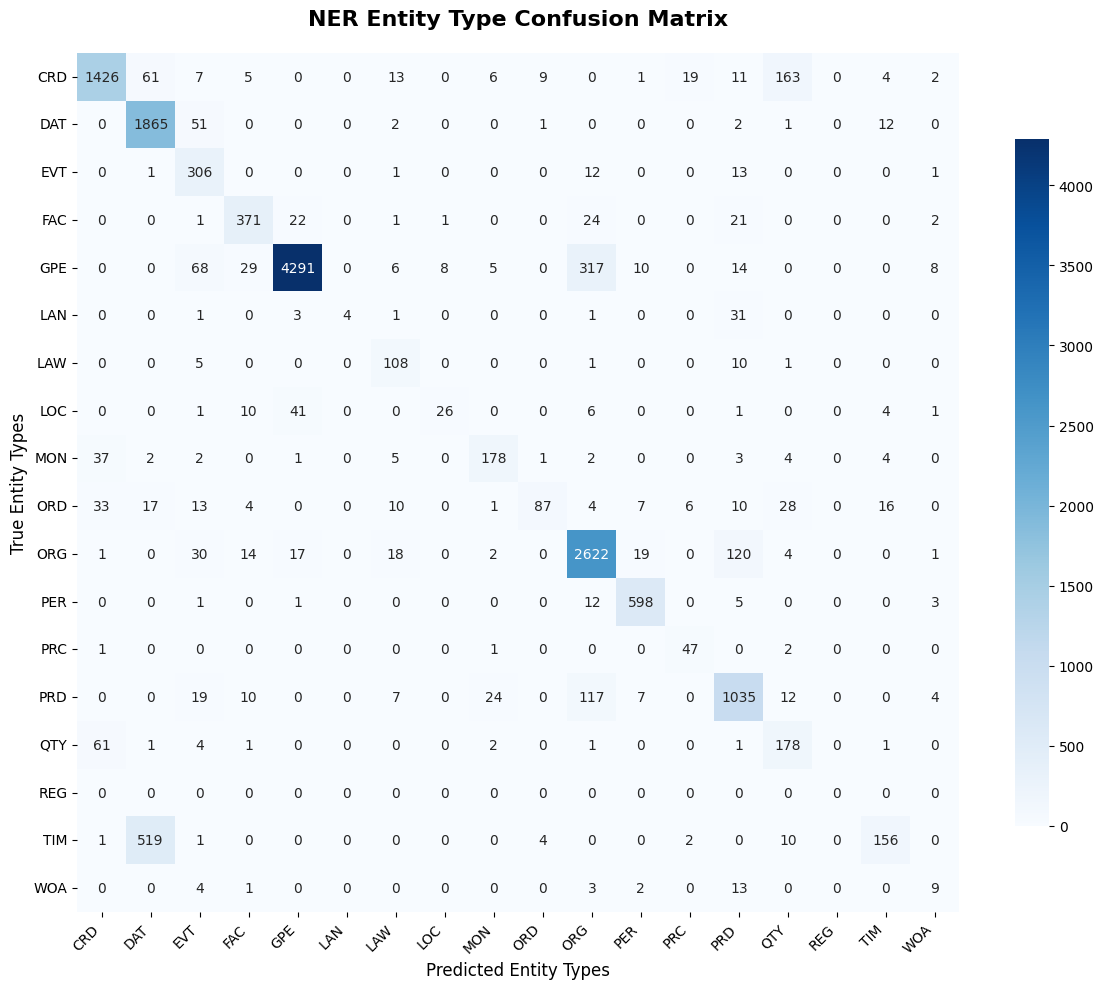


Entity Types Analysis:
  Predicted types: ['CRD', 'DAT', 'EVT', 'FAC', 'GPE', 'LAN', 'LAW', 'LOC', 'MON', 'ORD', 'ORG', 'PER', 'PRC', 'PRD', 'QTY', 'TIM', 'WOA']
  True types: ['CRD', 'DAT', 'EVT', 'FAC', 'GPE', 'LAN', 'LAW', 'LOC', 'MON', 'ORD', 'ORG', 'PER', 'PRC', 'PRD', 'QTY', 'REG', 'TIM', 'WOA']
  Total predicted types: 17
  Total true types: 18

Entity Type Counts:
Type       | Predicted | True
------------------------------
CRD        |      4212 | 2935
DAT        |     16887 | 7542
EVT        |     11434 | 4075
FAC        |      7913 | 3402
GPE        |     11088 | 7647
LAN        |         5 |  175
LAW        |      4728 | 1382
LOC        |      1013 |  810
MON        |      5529 | 2459
ORD        |       578 | 1225
ORG        |     31569 | 13136
PER        |     23055 | 7307
PRC        |      3785 | 1961
PRD        |     18185 | 9689
QTY        |      6394 | 3055
REG        |         0 |    1
TIM        |      1266 | 1688
WOA        |      2333 |  634

CONTOH 5 SAMPEL NER:


Processing: 100%|██████████| 2523/2523 [06:44<00:00,  6.24it/s]



Classification Report (Mapped Categories):
              precision    recall  f1-score   support

        bola       0.50      0.01      0.02       184
     edukasi       0.53      0.32      0.40       152
     finance       0.79      0.33      0.47       599
      health       0.32      0.64      0.43       174
     lainnya       0.12      0.54      0.19       160
   lifestyle       0.15      0.47      0.23       137
        news       0.71      0.15      0.24       424
    otomotif       0.78      0.26      0.38       176
    properti       0.60      0.15      0.23       144
   teknologi       0.54      0.37      0.44       164
      travel       0.41      0.55      0.47       174
        tren       0.05      0.20      0.08        35

    accuracy                           0.32      2523
   macro avg       0.46      0.33      0.30      2523
weighted avg       0.57      0.32      0.33      2523



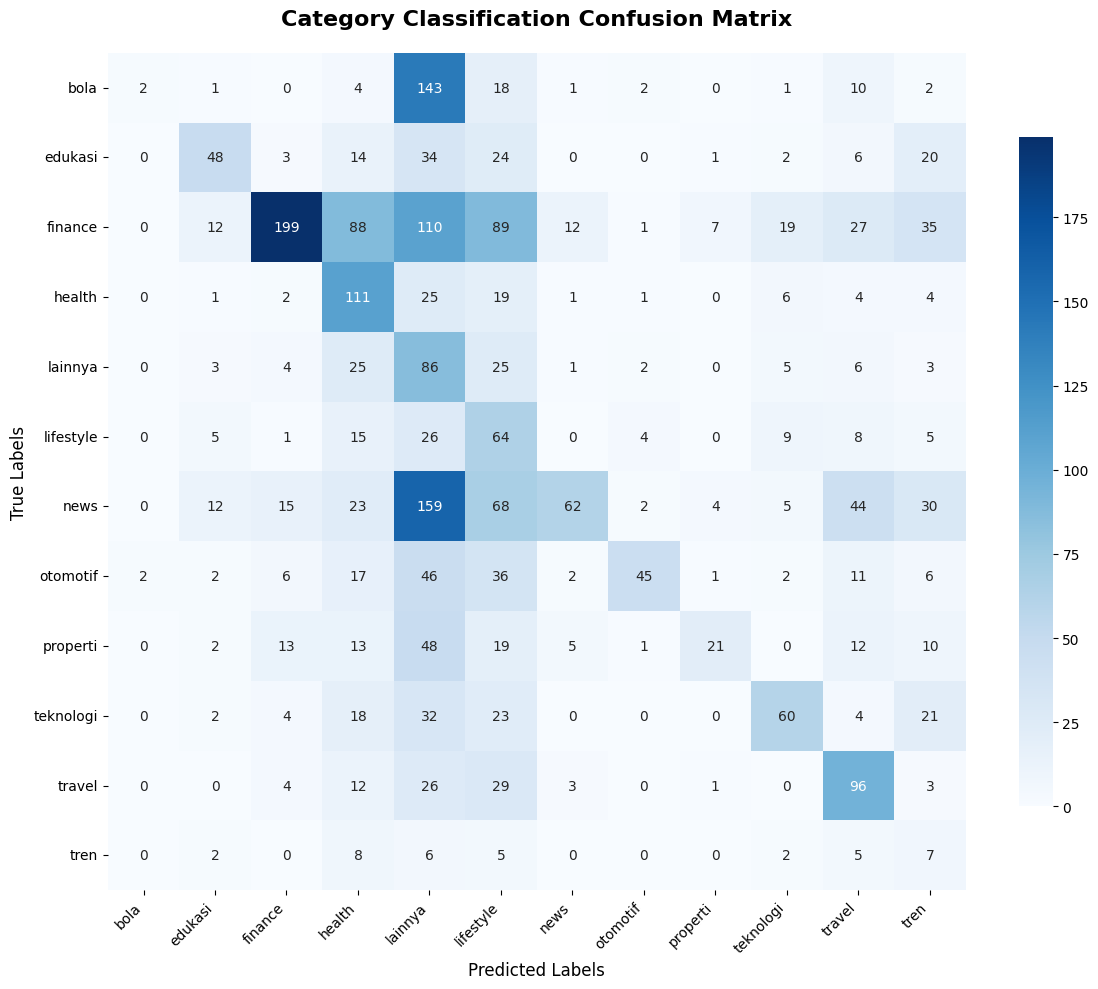


Summarization Report (ROUGE):
   ROUGE-1 : 56.60%
   ROUGE-2 : 42.73%
   ROUGE-L : 52.40%

Summarization samples: 251

Contoh Summary:

Sample 1:
Reference: BTN telah menyalurkan 93% atau Rp23,28 triliun dari dana Rp25 triliun dari pemerintah hingga 31 Oktober 2025, sesuai rencana kredit dan lebih cepat da...
Predicted: btn telah menyalurkan 93% dana pemerintah rp25 triliun dari pemerintah hingga 31 oktober 2025, sesuai jadwal kemenkeu. penyaluran sal pemerintah lebih...
--------------------------------------------------------------------------------

Sample 2:
Reference: PT Kilang Pertamina Internasional mendorong transisi energi melalui biofuel dan Green Refinery, dengan strategi co-processing dan conversion untuk pro...
Predicted: kpi mendorong transisi energi melalui biofuel dan green refinery, dengan strategi co-processing, conversion, dan conversion untuk produksi saf 2,4% sa...
--------------------------------------------------------------------------------

Sample 3:
Reference

In [14]:
# Train
train_df = train_df.copy()
train_df["category_mapped"] = train_df["category"].apply(map_category)
train_df["category"] = train_df["category_mapped"]

evaluate_ner_fast(pipeline_obj, train_df, batch_size=8)
evaluate_full_pipeline(pipeline_obj, train_df)

Running NER inference...


NER inference: 100%|██████████| 281/281 [00:07<00:00, 36.48it/s]


Processing gold entities...


Gold entities: 100%|██████████| 281/281 [00:00<00:00, 3174.29it/s]



HASIL NER (Entity-Level):
   Precision : 8.66%
   Recall    : 18.92%
   F1-Score  : 11.88%

NER Entity Type Confusion Matrix Analysis:
Total entity types: 17
Entity types: ['CRD', 'DAT', 'EVT', 'FAC', 'GPE', 'LAN', 'LAW', 'LOC', 'MON', 'ORD', 'ORG', 'PER', 'PRC', 'PRD', 'QTY', 'TIM', 'WOA']


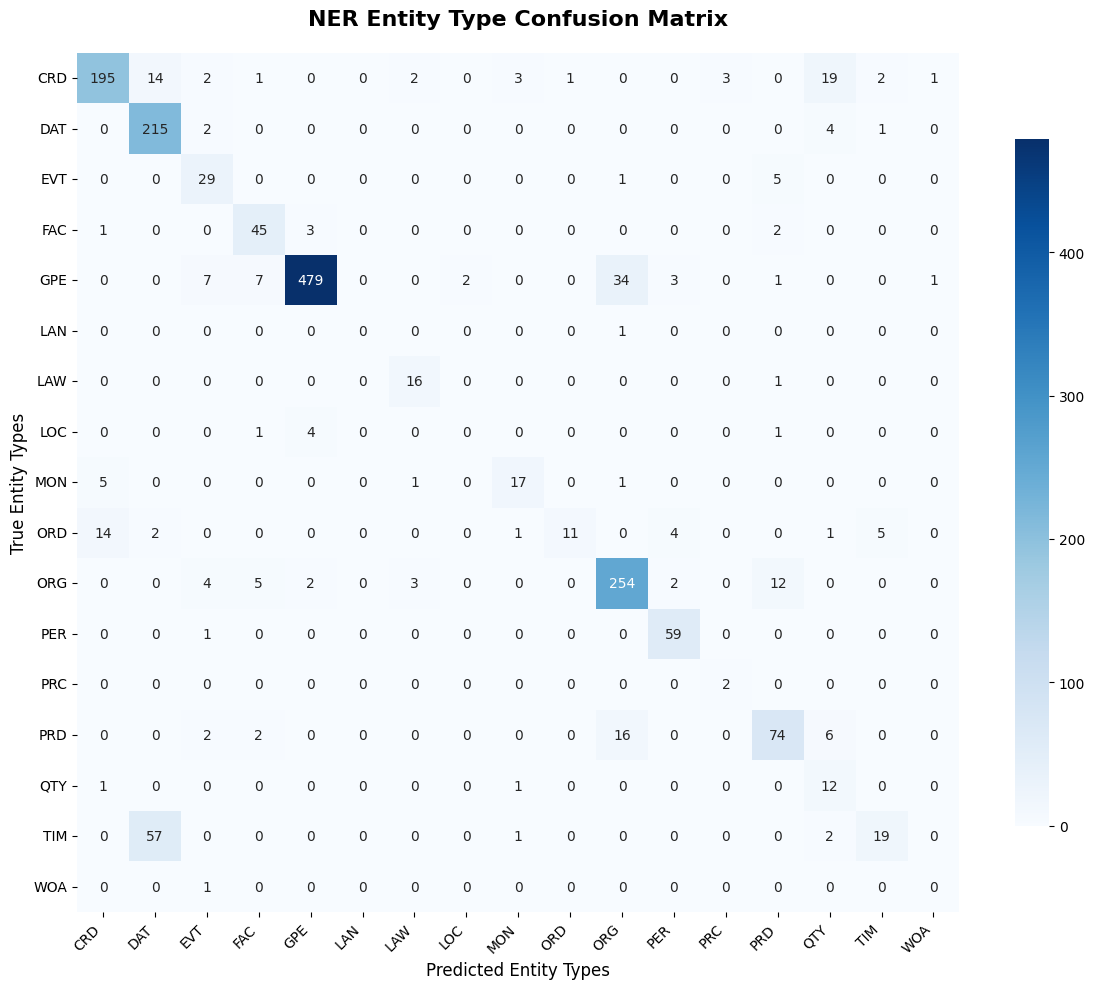


Entity Types Analysis:
  Predicted types: ['CRD', 'DAT', 'EVT', 'FAC', 'GPE', 'LAW', 'LOC', 'MON', 'ORD', 'ORG', 'PER', 'PRC', 'PRD', 'QTY', 'TIM', 'WOA']
  True types: ['CRD', 'DAT', 'EVT', 'FAC', 'GPE', 'LAN', 'LAW', 'LOC', 'MON', 'ORD', 'ORG', 'PER', 'PRC', 'PRD', 'QTY', 'TIM', 'WOA']
  Total predicted types: 16
  Total true types: 17

Entity Type Counts:
Type       | Predicted | True
------------------------------
CRD        |       578 |  433
DAT        |      1981 |  892
EVT        |      1199 |  435
FAC        |       887 |  407
GPE        |      1220 |  856
LAN        |         0 |   13
LAW        |       581 |  163
LOC        |       115 |   67
MON        |       842 |  388
ORD        |        56 |  145
ORG        |      3306 | 1361
PER        |      2951 |  902
PRC        |       493 |  231
PRD        |      1960 | 1036
QTY        |       702 |  317
TIM        |       174 |  194
WOA        |       283 |   92

CONTOH 5 SAMPEL NER:

Sample 1:
Text: Apa yang membuat sebuah dest

Processing: 100%|██████████| 281/281 [00:45<00:00,  6.18it/s]



Classification Report (Mapped Categories):
              precision    recall  f1-score   support

        bola       0.00      0.00      0.00        29
     edukasi       0.50      0.45      0.48        11
     finance       0.97      0.35      0.51        81
      health       0.30      0.68      0.42        22
     lainnya       0.03      0.12      0.04        17
   lifestyle       0.08      0.40      0.13        10
        news       0.50      0.08      0.14        38
    otomotif       1.00      0.25      0.40        16
    properti       0.75      0.16      0.26        19
   teknologi       0.50      0.25      0.33        16
      travel       0.26      0.35      0.30        20
        tren       0.00      0.00      0.00         2

    accuracy                           0.27       281
   macro avg       0.41      0.26      0.25       281
weighted avg       0.55      0.27      0.30       281



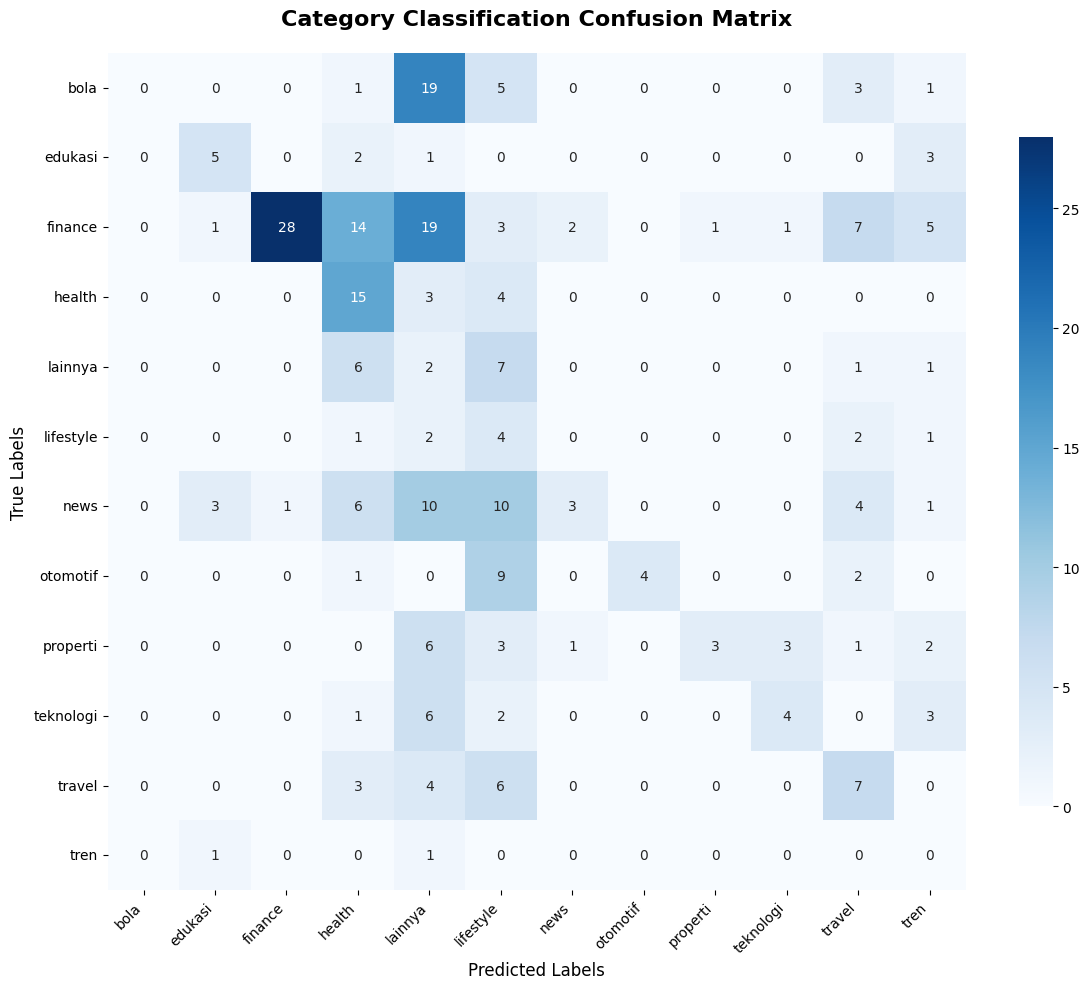


Summarization Report (ROUGE):
   ROUGE-1 : 32.61%
   ROUGE-2 : 12.96%
   ROUGE-L : 26.22%

Summarization samples: 29

Contoh Summary:

Sample 1:
Reference: Bitcoin anjlok 30% dari puncaknya, memicu kerugian trader pakai leverage. Meski harga turun ke $88.522, aktivitas spekulasi di bursa naik, terutama di...
Predicted: bitcoin turun 30% ke $30.000 pada oktober 2025, memicu spekulasi di bursa kripto luar negeri. open interest di binance naik $88.522, memicu spekulasi ...
--------------------------------------------------------------------------------

Sample 2:
Reference: Pengusaha sepatu lokal, David Chalik, menuding China melakukan dumping dengan menjual sepatu di bawah harga produksi di Indonesia, membuat produk loka...
Predicted: pengusaha sepatu lokal, david chalik, mencurigai gempuran sepatu impor yang hanya rp75 ribu per pasang karena mahal. ia khawatir praktik dumping di ch...
--------------------------------------------------------------------------------

Sample 3:
Reference:

In [15]:
# Val
val_df = val_df.copy()
val_df["category_mapped"] = val_df["category"].apply(map_category)
val_df["category"] = val_df["category_mapped"]

evaluate_ner_fast(pipeline_obj, val_df, batch_size=8)
evaluate_full_pipeline(pipeline_obj, val_df)

Running NER inference...


NER inference: 100%|██████████| 312/312 [00:09<00:00, 31.70it/s]


Processing gold entities...


Gold entities: 100%|██████████| 312/312 [00:00<00:00, 3166.16it/s]



HASIL NER (Entity-Level):
   Precision : 8.98%
   Recall    : 19.52%
   F1-Score  : 12.30%

NER Entity Type Confusion Matrix Analysis:
Total entity types: 17
Entity types: ['CRD', 'DAT', 'EVT', 'FAC', 'GPE', 'LAN', 'LAW', 'LOC', 'MON', 'ORD', 'ORG', 'PER', 'PRC', 'PRD', 'QTY', 'TIM', 'WOA']


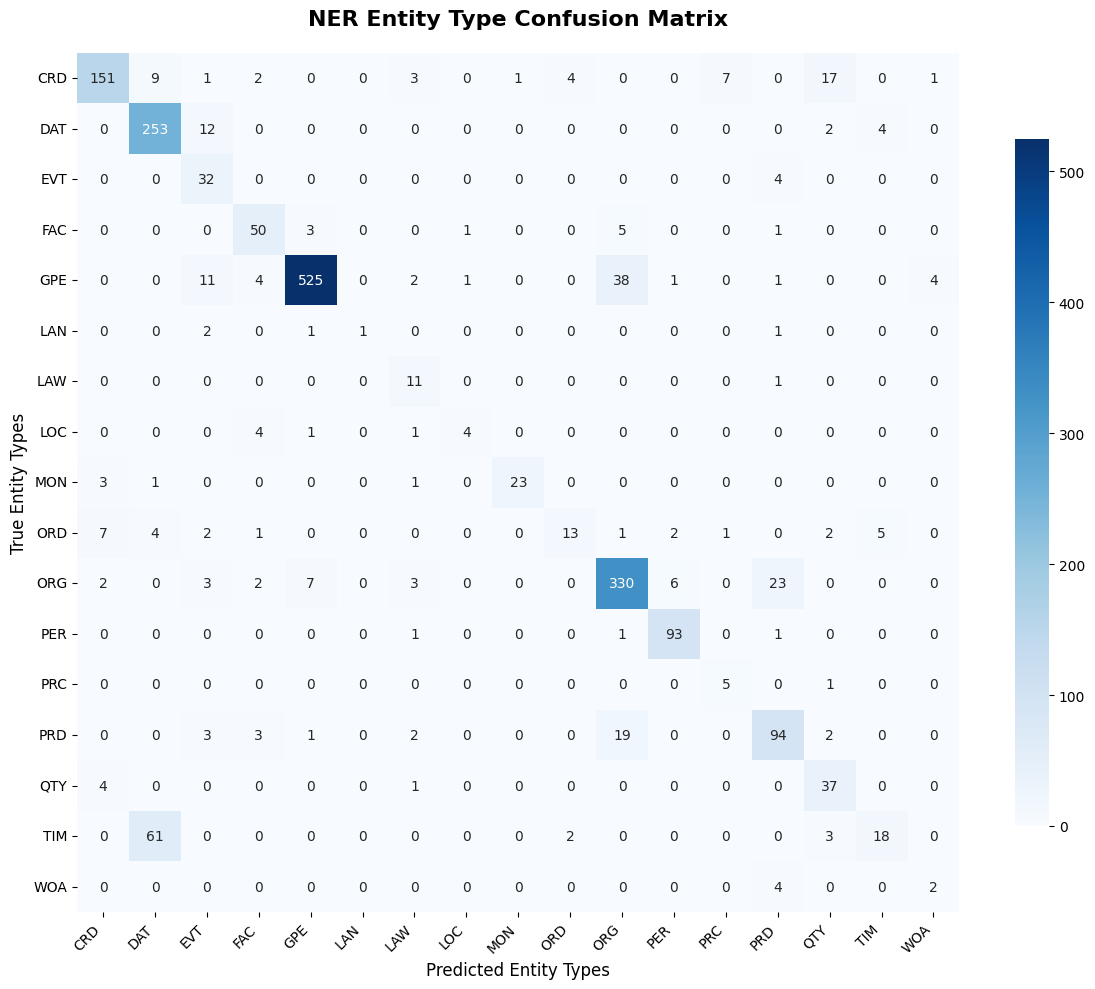


Entity Types Analysis:
  Predicted types: ['CRD', 'DAT', 'EVT', 'FAC', 'GPE', 'LAN', 'LAW', 'LOC', 'MON', 'ORD', 'ORG', 'PER', 'PRC', 'PRD', 'QTY', 'TIM', 'WOA']
  True types: ['CRD', 'DAT', 'EVT', 'FAC', 'GPE', 'LAN', 'LAW', 'LOC', 'MON', 'ORD', 'ORG', 'PER', 'PRC', 'PRD', 'QTY', 'TIM', 'WOA']
  Total predicted types: 17
  Total true types: 17

Entity Type Counts:
Type       | Predicted | True
------------------------------
CRD        |       458 |  352
DAT        |      2208 | 1010
EVT        |      1628 |  538
FAC        |      1114 |  482
GPE        |      1351 |  913
LAN        |         2 |   28
LAW        |       741 |  211
LOC        |       126 |  106
MON        |       619 |  275
ORD        |       100 |  159
ORG        |      4115 | 1752
PER        |      3095 | 1014
PRC        |       458 |  234
PRD        |      1944 | 1106
QTY        |       877 |  408
TIM        |       122 |  196
WOA        |       334 |   88

CONTOH 5 SAMPEL NER:

Sample 1:
Text: Strava merilis fitur 

Processing: 100%|██████████| 312/312 [00:51<00:00,  6.12it/s]



Classification Report (Mapped Categories):
              precision    recall  f1-score   support

        bola       0.00      0.00      0.00        27
     edukasi       0.43      0.25      0.32        12
     finance       0.81      0.28      0.41        94
      health       0.39      0.52      0.44        23
     lainnya       0.04      0.31      0.07        13
   lifestyle       0.15      0.69      0.25        13
        news       0.83      0.09      0.16        55
    otomotif       0.50      0.17      0.25        18
    properti       0.14      0.06      0.08        17
   teknologi       0.67      0.38      0.48        21
      travel       0.27      0.33      0.30        18
        tren       0.00      0.00      0.00         1

    accuracy                           0.25       312
   macro avg       0.35      0.26      0.23       312
weighted avg       0.54      0.25      0.28       312



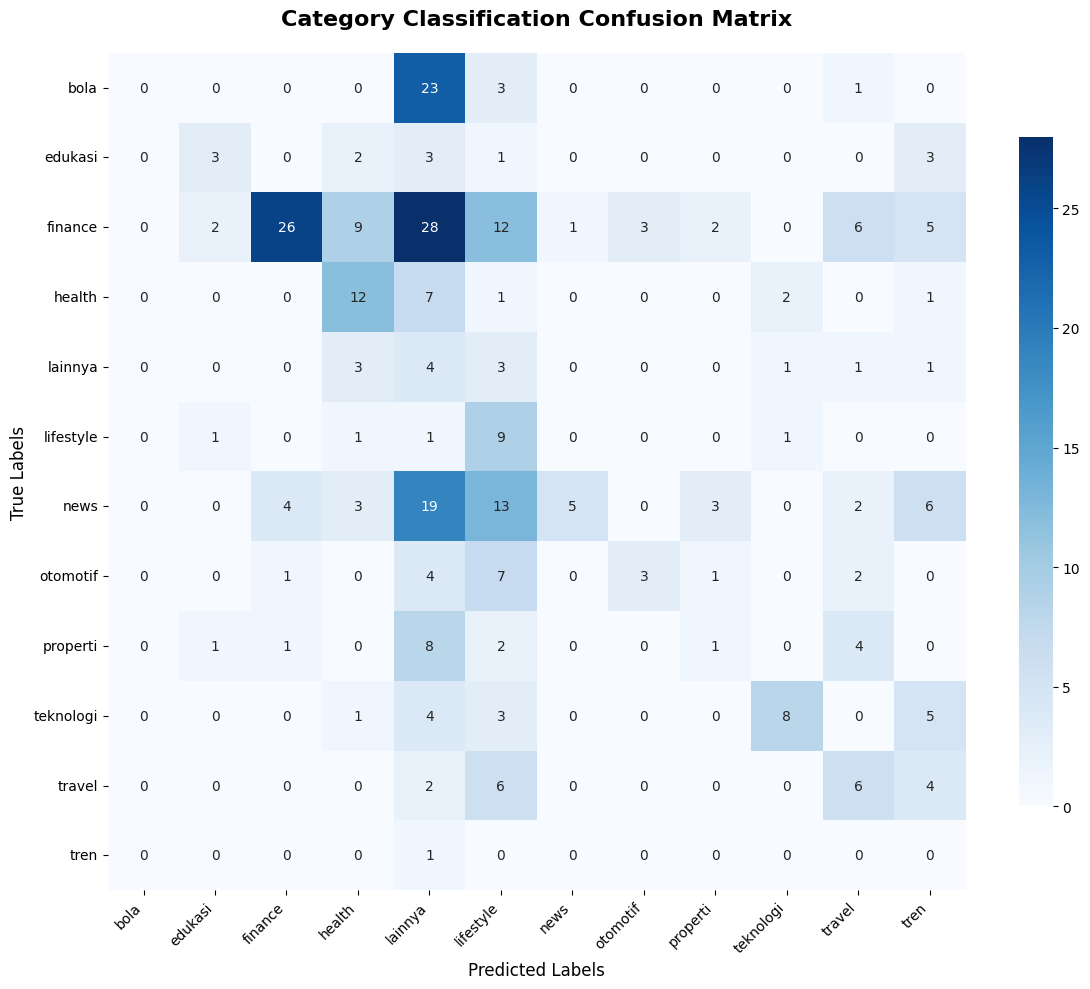


Summarization Report (ROUGE):
   ROUGE-1 : 40.61%
   ROUGE-2 : 19.13%
   ROUGE-L : 32.80%

Summarization samples: 32

Contoh Summary:

Sample 1:
Reference: PT PP menyelesaikan revitalisasi Terminal 1C Bandara Soekarno-Hatta senilai Rp1,3 triliun, meningkatkan kapasitas dari 3 juta ke 8 juta penumpang per ...
Predicted: pt pp proyek revitalisasi terminal 1c bandara soekarno-hatta selesai pada 18 april 2025, meningkatkan kapasitas terminal menjadi 8 juta penumpang per ...
--------------------------------------------------------------------------------

Sample 2:
Reference: Bank Mandiri merayakan ulang tahun ke-27 dengan empat program TJSL nasional bertema "Sinergi Majukan Negeri", menjangkau 60.000 lebih penerima manfaat...
Predicted: bank mandiri menggelar empat program, yakni pasar murah mandiri, pasar murah mandiri, pasar murah, pasar murah, pasar murah, pasar murah, pasar murah,...
--------------------------------------------------------------------------------

Sample 3:
Reference:

In [16]:
# Test
test_df = test_df.copy()
test_df["category_mapped"] = test_df["category"].apply(map_category)
test_df["category"] = test_df["category_mapped"]

evaluate_ner_fast(pipeline_obj, test_df, batch_size=8)
evaluate_full_pipeline(pipeline_obj, test_df)

In [17]:
# UJI COBA

# Contoh Teks 1: Berita Umum (Harus diskip summary-nya)
sample_text_general = """
Harga aneka smartphone Xiaomi yang dipasarkan tahun depan akan mengalami kenaikan. Pernyataan ini disampaikan oleh Presiden Xiaomi, Lu Weibing dalam konferensi pers terkait laporan pendapatan perusahaan.
Kenaikan hargaHPXiaomidipicu oleh meningkatnya harga chip memori, seiring dengan lonjakan permintaan komponen ini untuk server kecerdasan buatan (AI) yang diperlukan oleh perusahaan teknologi untuk membangun data center.
Tingginya permintaan chip memori untuk server juga membuat perusahaan seperti Samsung, memangkas produksi chip memori termasuk untuk ponsel, dan mengalihkannya ke memori bandwidth tinggi (high bandwidth memory).
Karena kondisi itu, Weibing lantas memperingatkan pengguna akan kenaikan harga ponsel Xiaomi.
""Saya memperkirakan tekanan akan jauh lebih berat tahun depan dibanding tahun ini,"" kata Weibing, dikutipKompasTeknodariReuters.
""Secara umum, konsumen mungkin akan mendapati kenaikan harga ecer produk yang cukup besar. Sebagian tekanan mungkin harus diatasi melalui kenaikan harga, walaupun cara ini saja tidak akan cukup untuk mengatasinya,"" jelas bos Xiaomi itu.
Bukan kali ini saja, bulan lalu Weibing juga memaparkan bahwa melonjaknya harga chip memori mendesak kenaikan hargasmartphone. Pernyataan ini mencuat usai sejumlah konsumen mengaku kecewa dengan harga Redmi K90.
KOMPAS.com/Caroline Saskia TanotoIlustrasi smartphone yang cukup diminati di ITC Roxy Mas
Ponsel andalan dari sub-merek Xiaomi itu dibanderol 2.599 yuan (sekitar Rp 6,1 juta) untuk versi dasarnya dengan RAM 12/256 GB. Harganya naik dari 2.499 yuan (sekitar Rp 5,8 juta) dibanding pendahulunya, Redmi K80 yang rilis November 2024 lalu.
Walau memberikan peringatan kenaikan harga, Weibing tak merinci persentase lonjakanharga HP Xiaomidi tahun depan. Tak dirinci pula apakah lonjakan harga HP Xiaomi akan berlaku secara global termasuk Indonesia, atau hanya di pasar tertentu saja.
Di tengah tekanan harga komponen, Xiaomi tetap catatkan pertumbuhan pengiriman. Laporan dari firma riset pasar Omdia menyebut Xiaomi berhasil mengirimkan 43,4 juta unit ponsel pada kuartal III-2025.
Angka tersebut mencerminkan kenaikan 1 persen dibandingkan periode yang sama tahun lalu. Dengan total pengiriman tersebut, Xiaomi mampu meraih pangsa pasar smartphone global sebesar 14 persen, dan berada di posisi ketiga.
Posisi pertama adalah Samsung dengan pengiriman 60,6 juta unit ponsel (market share 19 persen), disusul Apple sebesar 56,5 juta unit (pangsa pasar 18 persen).
Posisi keempat ada Transsion dengan pengiriman 28,6 juta unit (pangsa pasar 9 persen), yang disusul Vivo dengan pengiriman 28,5 juta unit (pangsa pasar 9 persen)."""

# Contoh Teks 2: Berita Saham (Harus diringkas)
sample_text_market = """
PT Bank Syariah Indonesia Tbk (BSI) menjalin kerja sama dengan Kementerian Haji dan Umrah Republik Indonesia (Kemenhaj) untuk memperkuat digitalisasi layanan keuangan bagi jamaah haji asal Indonesia. Penandatanganan nota kesepahaman tersebut dilakukan di Jakarta dan menjadi bagian dari persiapan penyelenggaraan haji 2026.
Kesepakatan ini ditandatangani oleh Direktur UtamaBSIAnggoro Eko Cahyo dan Menteri Haji dan Umrah Mochamad Irfan Yusuf. Kedua pihak menyetujui kolaborasi dalam operasional transaksi kelembagaan, penyediaan akses layanan haji bagi calon jamaah, serta pemanfaatan produk keuangan syariah BSI.
Penandatanganan ini sekaligus menandai dimulainya tahap awal layanan haji 2026. Pemerintah menetapkan Biaya Penyelenggaraan Ibadah Haji (Bipih) 2026 sebesar Rp 87.409.365,45 per jamaah.
Rata-rata jamaah membayar Rp 54.193.806,58, sementara sisanya ditutup dari nilai manfaat dana haji. Bipih tahun ini lebih rendah sekitar Rp 2 juta dibandingkan tahun sebelumnya, dan proses pelunasan diperkirakan dimulai pada pekan keempat November 2025.
Direktur Utama BSI Anggoro Eko Cahyo menyatakan apresiasinya terhadap kerja sama tersebut karena dinilai memperkuat layanan bagi jamaah Indonesia yang menjadi salah satu rombongan terbesar setiap tahun.
“Kami berkomitmen menyediakan layanan perbankan syariah yang lebih cepat, aman, dan terkoneksi dengan sistem di Arab Saudi sehingga jamaah dapat beribadah dengan tenang dan juga dapat melakukan transaksi keuangan di Arab Saudi secara aman,” ujarnya, melalui keterangan pers, dikutip Sabtu (22/11/2025).
BSI telah menyiapkan berbagai kanal untuk pelunasan biaya haji, baik secara offline, online, maupun melalui BSI Agen yang tersebar di seluruh Indonesia.
Menteri Haji dan Umrah Mochamad Irfan Yusuf menegaskan komitmen pemerintah untuk terus meningkatkan kualitas layanan bagi jamaah Indonesia.
“Sebagai salah satu negara dengan jumlah penduduk Muslim terbesar di dunia, Indonesia memiliki posisi strategis dalam penyelenggaraan ibadah haji, sehingga peningkatan pelayanan haji dan umrah menjadi prioritas utama kami setiap tahun,” ujarnya.
Ia berharap kolaborasi dengan BSI sebagai bank syariah terbesar dapat memberi kemudahan tambahan bagi jamaah. “Kami berharap BSI juga dapat mempermudah jamaah baik di Tanah Air maupun saat berada di Tanah Suci,” katanya.
BSI saat ini menjadi market leader layanan perbankan jamaah haji. Rata-rata 83 persen calon haji Indonesia menggunakan layanan BSI untuk keberangkatan ke Arab Saudi. Di sisi tabungan haji, BSI mengelola lebih dari 6,7 juta rekening, dengan sekitar 51 persen di antaranya sudah masuk daftar tunggu.
"""

print("\n=== TEST 1: MARKET NEWS ===")
res1 = pipeline_obj.run_single(sample_text_market)
print(json.dumps(res1, indent=2))

print("\n=== TEST 2: GENERAL NEWS ===")
res2 = pipeline_obj.run_single(sample_text_general)
print(json.dumps(res2, indent=2))


=== TEST 1: MARKET NEWS ===
{
  "ner": "[{\"entity\": \"PT\", \"type\": \"ORG\"}, {\"entity\": \"Bank\", \"type\": \"ORG\"}, {\"entity\": \"Syariah\", \"type\": \"ORG\"}, {\"entity\": \"Indonesia\", \"type\": \"ORG\"}, {\"entity\": \"Tbk\", \"type\": \"ORG\"}, {\"entity\": \"B\", \"type\": \"ORG\"}, {\"entity\": \"SI\", \"type\": \"ORG\"}, {\"entity\": \"Kementerian\", \"type\": \"ORG\"}, {\"entity\": \"Haji\", \"type\": \"ORG\"}, {\"entity\": \"dan\", \"type\": \"ORG\"}, {\"entity\": \"Umrah\", \"type\": \"ORG\"}, {\"entity\": \"Republik\", \"type\": \"ORG\"}, {\"entity\": \"Indonesia\", \"type\": \"GPE\"}, {\"entity\": \"Kemen\", \"type\": \"ORG\"}, {\"entity\": \"h\", \"type\": \"ORG\"}, {\"entity\": \"aj\", \"type\": \"ORG\"}, {\"entity\": \"Indonesia\", \"type\": \"GPE\"}, {\"entity\": \"Jakarta\", \"type\": \"GPE\"}, {\"entity\": \"2026\", \"type\": \"DAT\"}, {\"entity\": \"B\", \"type\": \"ORG\"}, {\"entity\": \"SI\", \"type\": \"ORG\"}, {\"entity\": \"Angg\", \"type\": \"PER\"

GENERATING COMPREHENSIVE VISUALIZATION REPORT
ANALYZING ENTITY TYPE DISTRIBUTION


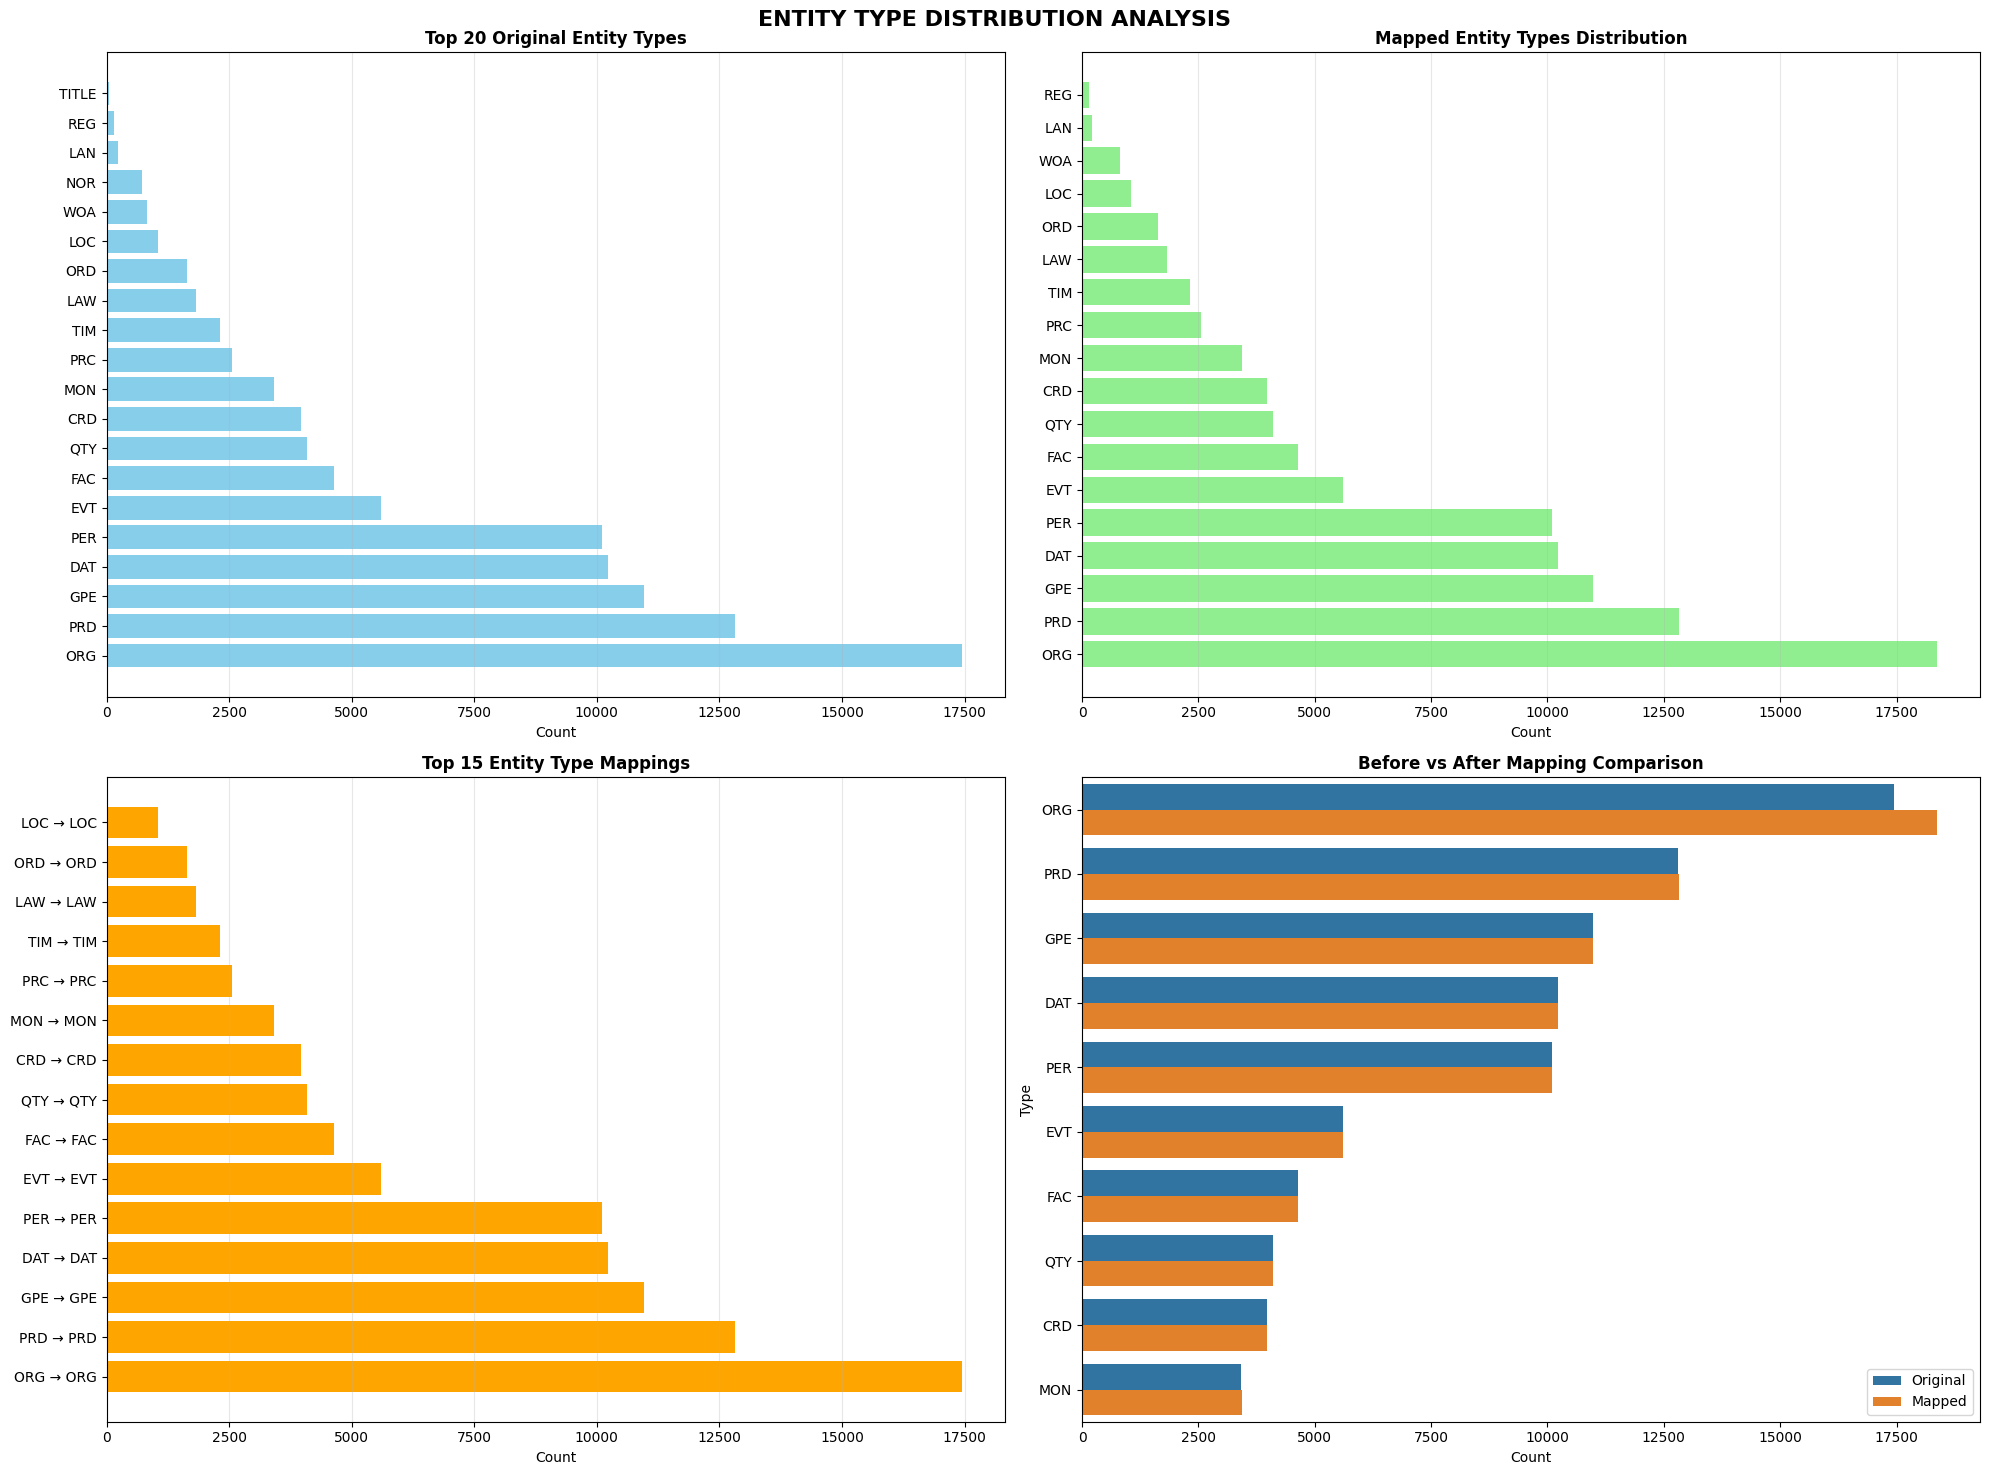


ENTITY TYPE STATISTICS:
Total unique original types: 58
Total unique mapped types: 18
Reduction in type count: 40 types

Top 10 Original Types:
   1. ORG             → ORG        :  17444 entities
   2. PRD             → PRD        :  12815 entities
   3. GPE             → GPE        :  10969 entities
   4. DAT             → DAT        :  10234 entities
   5. PER             → PER        :  10103 entities
   6. EVT             → EVT        :   5606 entities
   7. FAC             → FAC        :   4634 entities
   8. QTY             → QTY        :   4093 entities
   9. CRD             → CRD        :   3964 entities
  10. MON             → MON        :   3420 entities

Top 10 Mapped Types:
   1. ORG             :  18375 entities
   2. PRD             :  12817 entities
   3. GPE             :  10969 entities
   4. DAT             :  10234 entities
   5. PER             :  10103 entities
   6. EVT             :   5606 entities
   7. FAC             :   4634 entities
   8. QTY             :

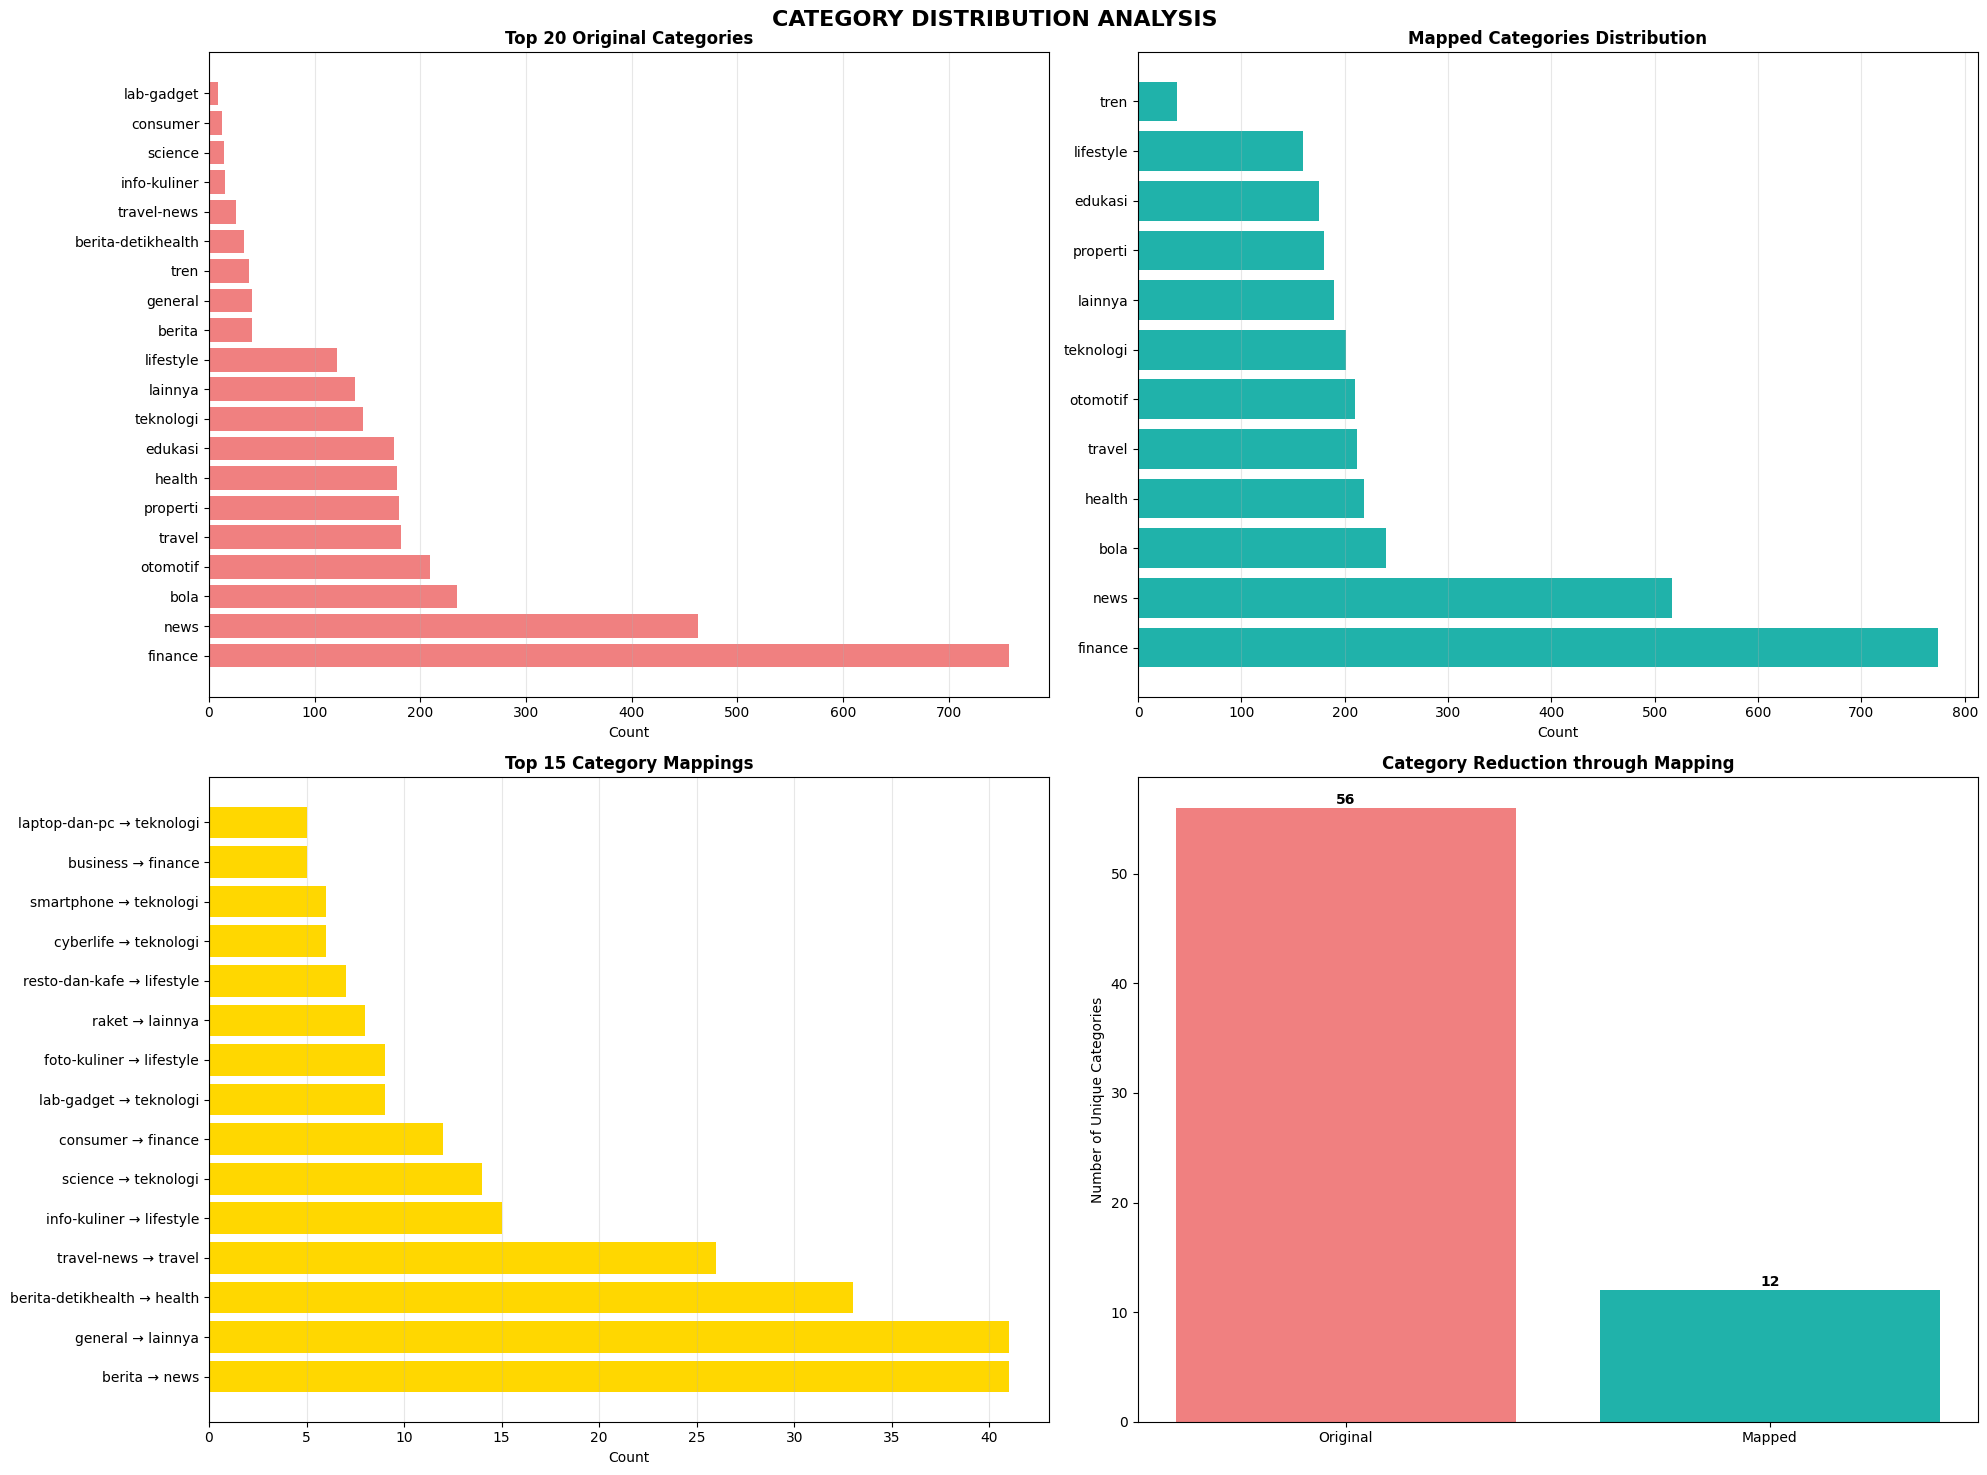


CATEGORY STATISTICS:
Total unique original categories: 56
Total unique mapped categories: 12
Reduction in category count: 44 categories

Top 10 Original Categories:
   1. finance                        → finance         :    757 articles
   2. news                           → news            :    463 articles
   3. bola                           → bola            :    235 articles
   4. otomotif                       → otomotif        :    209 articles
   5. travel                         → travel          :    182 articles
   6. properti                       → properti        :    180 articles
   7. health                         → health          :    178 articles
   8. edukasi                        → edukasi         :    175 articles
   9. teknologi                      → teknologi       :    146 articles
  10. lainnya                        → lainnya         :    138 articles

Mapped Categories Distribution:
   1. finance         :    774 articles (24.8%)
   2. news            :

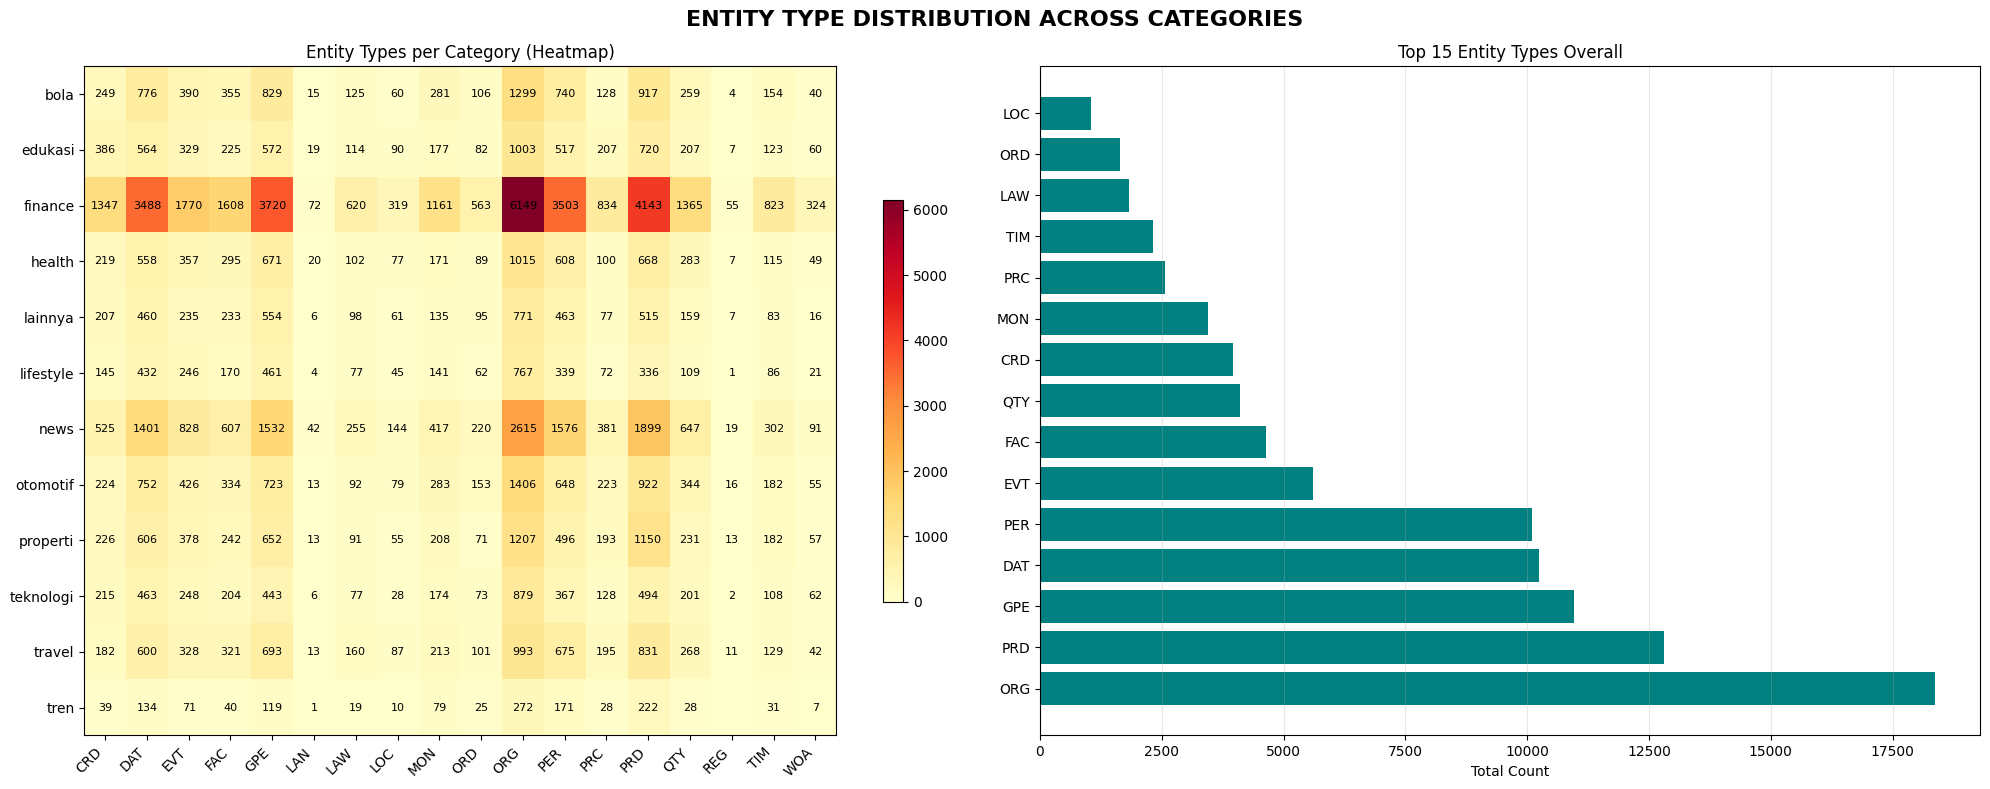


ENTITY-CATEGORY INSIGHTS:
  bola           : ORG(1299), PRD(917), GPE(829)
  edukasi        : ORG(1003), PRD(720), GPE(572)
  finance        : ORG(6149), PRD(4143), GPE(3720)
  health         : ORG(1015), GPE(671), PRD(668)
  lainnya        : ORG(771), GPE(554), PRD(515)

MAPPING CONFIGURATION SUMMARY

ENTITY TYPE MAPPING GROUPS:
  CRD        ← CRD
  DAT        ← DAY, DAT
  EVT        ← PLAN, PROC, EVT
  FAC        ← HOT, FAC
  GPE        ← GPE
  LAN        ← LAN
  LAW        ← LA, LAW
  LOC        ← LOC
  MON        ← CUR, MON
  ORD        ← ORD
  ORG        ← COL, LEAGUE, NOR +5 more
  PER        ← PER
  PRC        ← PRC, RAT
  PRD        ← BEA, PRD, PROD +1 more
  QTY        ← AGE, QTY
  REG        ← CULT, REG, REL
  TIM        ← TIM
  WEB        ← URL, WEB
  WOA        ← WAA, WAO, WGA +6 more

CATEGORY MAPPING GROUPS:
  bola            ← sport-lain, sportstyle +1 more
  finance         ← business, consumer
  health          ← berita-detikhealth, fotohealth +2 more
  lifestyle     

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from collections import Counter, defaultdict

# ENTITY TYPE MAPPING CONFIGURATION
ENTITY_TYPE_MAPPING = {
    # Mapping dari entity types di data ke standard types
    "AGE": "QTY",      # Age -> Quantity
    "BEA": "PRD",      # Beast -> Product  
    "COL": "ORG",      # College -> Organization
    "CULT": "REG",     # Culture -> Religion
    "CUR": "MON",      # Currency -> Money
    "DAY": "DAT",      # Day -> Date
    "HOT": "FAC",      # Hotel -> Facility
    "LA": "LAW",       # Law -> Law Entity
    "LAN": "LAN",      # Language -> Language (same)
    "LAW": "LAW",      # Law -> Law Entity (same)
    "LEAGUE": "ORG",   # League -> Organization
    "NOR": "ORG",      # Political Organization -> Organization
    "ORD": "ORD",      # Ordinal -> Ordinal (same)
    "ORF": "ORG",      # Organization Formal -> Organization
    "ORG": "ORG",      # Organization -> Organization (same)
    "PER": "PER",      # Person -> Person (same)
    "PLAN": "EVT",     # Plan -> Event
    "POL": "ORG",      # Political -> Organization
    "POR": "ORG",      # Portfolio -> Organization
    "PRC": "PRC",      # Percent -> Percent (same)
    "PRD": "PRD",      # Product -> Product (same)
    "PRO": "ORG",      # Professional -> Organization
    "PROC": "EVT",     # Process -> Event
    "PROD": "PRD",     # Product -> Product (same)
    "QTY": "QTY",      # Quantity -> Quantity (same)
    "RAT": "PRC",      # Rate -> Percent
    "REG": "REG",      # Region -> Geopolitical Entity
    "REL": "REG",      # Religion -> Religion
    "TECH": "PRD",     # Technology -> Product
    "TIM": "TIM",      # Time -> Time (same)
    "URL": "WEB",      # URL -> Web
    "WAA": "WOA",      # Work of Art -> Work of Art
    "WAO": "WOA",      # Work of Art -> Work of Art
    "WEB": "WEB",      # Web -> Web (same)
    "WGA": "WOA",      # Work of Art -> Work of Art
    "WOA": "WOA",      # Work of Art -> Work of Art (same)
    "WOK": "WOA",      # Work of Art -> Work of Art
    "WOP": "WOA",      # Work of Art -> Work of Art
    "WP": "WOA",       # Work of Art -> Work of Art
    "WPA": "WOA",      # Work of Art -> Work of Art
    "WQA": "WOA",      # Work of Art -> Work of Art
    
    # Standard types dari prompt
    "CRD": "CRD",
    "DAT": "DAT", 
    "EVT": "EVT",
    "FAC": "FAC",
    "GPE": "GPE",
    "LOC": "LOC",
    "MON": "MON",
}

# Target entity types sesuai prompt
TARGET_ENTITY_TYPES = {
    "CRD", "DAT", "EVT", "FAC", "GPE", "LAW", "LOC", "MON", 
    "NOR", "ORD", "ORG", "PER", "PRC", "PRD", "QTY", "REG", 
    "TIM", "WOA", "LAN"
}

def map_entity_type(entity_type):
    """Map entity type ke standard type"""
    mapped = ENTITY_TYPE_MAPPING.get(entity_type, entity_type)
    if mapped not in TARGET_ENTITY_TYPES:
        return "ORG"
    return mapped

def norm_type(t):
    """Normalize type dengan mapping"""
    original_norm = t.upper().replace(" ", "_").replace("/", "_")
    return map_entity_type(original_norm)

def visualize_entity_type_distribution(raw_datasets):
    """Visualisasi distribusi tipe entitas sebelum dan sesudah mapping"""
    
    print("ANALYZING ENTITY TYPE DISTRIBUTION")
    print("=" * 60)
    
    # Kumpulkan semua entity types dari dataset
    original_types = Counter()
    mapped_types = Counter()
    
    for split in ["train", "validation", "test"]:
        if split in raw_datasets:
            for example in raw_datasets[split]:
                ents = parse_ner_field(example["ner"])
                for ent in ents:
                    original_type = ent.get("type", "").strip().upper()
                    if original_type:
                        original_types[original_type] += 1
                        mapped_type = norm_type(original_type)
                        mapped_types[mapped_type] += 1
    
    # Filter hanya types yang ada di mapping
    original_in_mapping = Counter()
    for orig_type, count in original_types.items():
        if orig_type in ENTITY_TYPE_MAPPING:
            original_in_mapping[orig_type] = count
    
    # Buat visualisasi
    fig, axes = plt.subplots(2, 2, figsize=(20, 15))
    fig.suptitle('ENTITY TYPE DISTRIBUTION ANALYSIS', fontsize=16, fontweight='bold')
    
    # Plot 1: Original Entity Types (Top 20)
    if original_types:
        orig_df = pd.DataFrame(original_types.most_common(20), columns=['Type', 'Count'])
        axes[0, 0].barh(orig_df['Type'], orig_df['Count'], color='skyblue')
        axes[0, 0].set_title('Top 20 Original Entity Types', fontweight='bold')
        axes[0, 0].set_xlabel('Count')
        axes[0, 0].grid(axis='x', alpha=0.3)
    
    # Plot 2: Mapped Entity Types
    if mapped_types:
        mapped_df = pd.DataFrame(mapped_types.most_common(), columns=['Type', 'Count'])
        axes[0, 1].barh(mapped_df['Type'], mapped_df['Count'], color='lightgreen')
        axes[0, 1].set_title('Mapped Entity Types Distribution', fontweight='bold')
        axes[0, 1].set_xlabel('Count')
        axes[0, 1].grid(axis='x', alpha=0.3)
    
    # Plot 3: Mapping Transformation (Top mappings)
    mapping_counts = Counter()
    for orig_type, count in original_types.items():
        if orig_type in ENTITY_TYPE_MAPPING:
            mapped = ENTITY_TYPE_MAPPING[orig_type]
            mapping_counts[f"{orig_type} → {mapped}"] += count
    
    if mapping_counts:
        mapping_df = pd.DataFrame(mapping_counts.most_common(15), columns=['Mapping', 'Count'])
        axes[1, 0].barh(mapping_df['Mapping'], mapping_df['Count'], color='orange')
        axes[1, 0].set_title('Top 15 Entity Type Mappings', fontweight='bold')
        axes[1, 0].set_xlabel('Count')
        axes[1, 0].grid(axis='x', alpha=0.3)
    
    # Plot 4: Before vs After Mapping Comparison
    top_original = dict(original_types.most_common(10))
    top_mapped = dict(mapped_types.most_common(10))
    
    comparison_data = []
    for orig_type, count in top_original.items():
        comparison_data.append({'Type': orig_type, 'Count': count, 'Stage': 'Original'})
    for mapped_type, count in top_mapped.items():
        comparison_data.append({'Type': mapped_type, 'Count': count, 'Stage': 'Mapped'})
    
    if comparison_data:
        comp_df = pd.DataFrame(comparison_data)
        sns.barplot(data=comp_df, x='Count', y='Type', hue='Stage', ax=axes[1, 1])
        axes[1, 1].set_title('Before vs After Mapping Comparison', fontweight='bold')
        axes[1, 1].set_xlabel('Count')
        axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nENTITY TYPE STATISTICS:")
    print(f"Total unique original types: {len(original_types)}")
    print(f"Total unique mapped types: {len(mapped_types)}")
    print(f"Reduction in type count: {len(original_types) - len(mapped_types)} types")
    
    print(f"\nTop 10 Original Types:")
    for i, (typ, count) in enumerate(original_types.most_common(10), 1):
        mapped = norm_type(typ)
        print(f"  {i:2}. {typ:15} → {mapped:10} : {count:6} entities")
    
    print(f"\nTop 10 Mapped Types:")
    for i, (typ, count) in enumerate(mapped_types.most_common(10), 1):
        print(f"  {i:2}. {typ:15} : {count:6} entities")

def visualize_category_distribution(df_processed):
    """Visualisasi distribusi kategori sebelum dan sesudah mapping"""
    
    print("\nANALYZING CATEGORY DISTRIBUTION")
    print("=" * 60)
    
    # Hitung distribusi kategori
    original_cats = Counter(df_processed["category"])
    mapped_cats = Counter(df_processed["category_mapped"])
    
    # Buat visualisasi
    fig, axes = plt.subplots(2, 2, figsize=(20, 15))
    fig.suptitle('CATEGORY DISTRIBUTION ANALYSIS', fontsize=16, fontweight='bold')
    
    # Plot 1: Original Categories (Top 20)
    if original_cats:
        orig_cat_df = pd.DataFrame(original_cats.most_common(20), columns=['Category', 'Count'])
        axes[0, 0].barh(orig_cat_df['Category'], orig_cat_df['Count'], color='lightcoral')
        axes[0, 0].set_title('Top 20 Original Categories', fontweight='bold')
        axes[0, 0].set_xlabel('Count')
        axes[0, 0].grid(axis='x', alpha=0.3)
    
    # Plot 2: Mapped Categories
    if mapped_cats:
        mapped_cat_df = pd.DataFrame(mapped_cats.most_common(), columns=['Category', 'Count'])
        axes[0, 1].barh(mapped_cat_df['Category'], mapped_cat_df['Count'], color='lightseagreen')
        axes[0, 1].set_title('Mapped Categories Distribution', fontweight='bold')
        axes[0, 1].set_xlabel('Count')
        axes[0, 1].grid(axis='x', alpha=0.3)
    
    # Plot 3: Category Mapping Transformation
    mapping_cat_counts = Counter()
    for orig_cat in original_cats:
        mapped_cat = map_category(orig_cat)
        if orig_cat != mapped_cat:  # Hanya tampilkan yang berubah
            mapping_cat_counts[f"{orig_cat} → {mapped_cat}"] += original_cats[orig_cat]
    
    if mapping_cat_counts:
        mapping_cat_df = pd.DataFrame(mapping_cat_counts.most_common(15), columns=['Mapping', 'Count'])
        axes[1, 0].barh(mapping_cat_df['Mapping'], mapping_cat_df['Count'], color='gold')
        axes[1, 0].set_title('Top 15 Category Mappings', fontweight='bold')
        axes[1, 0].set_xlabel('Count')
        axes[1, 0].grid(axis='x', alpha=0.3)
    
    # Plot 4: Category Reduction Analysis
    reduction_data = [
        {'Stage': 'Original', 'Count': len(original_cats), 'Description': 'Unique Categories'},
        {'Stage': 'Mapped', 'Count': len(mapped_cats), 'Description': 'Unique Categories'}
    ]
    reduction_df = pd.DataFrame(reduction_data)
    axes[1, 1].bar(reduction_df['Stage'], reduction_df['Count'], color=['lightcoral', 'lightseagreen'])
    axes[1, 1].set_title('Category Reduction through Mapping', fontweight='bold')
    axes[1, 1].set_ylabel('Number of Unique Categories')
    
    # Tambah nilai di atas bar
    for i, count in enumerate(reduction_df['Count']):
        axes[1, 1].text(i, count + 0.1, str(count), ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nCATEGORY STATISTICS:")
    print(f"Total unique original categories: {len(original_cats)}")
    print(f"Total unique mapped categories: {len(mapped_cats)}")
    print(f"Reduction in category count: {len(original_cats) - len(mapped_cats)} categories")
    
    print(f"\nTop 10 Original Categories:")
    for i, (cat, count) in enumerate(original_cats.most_common(10), 1):
        mapped = map_category(cat)
        print(f"  {i:2}. {cat:30} → {mapped:15} : {count:6} articles")
    
    print(f"\nMapped Categories Distribution:")
    for i, (cat, count) in enumerate(mapped_cats.most_common(), 1):
        percentage = (count / len(df_processed)) * 100
        print(f"  {i:2}. {cat:15} : {count:6} articles ({percentage:.1f}%)")

def visualize_entity_category_relationship(df_processed, raw_datasets):
    """Visualisasi hubungan antara entity types dan categories"""
    
    print("\nANALYZING ENTITY-CATEGORY RELATIONSHIP")
    print("=" * 60)
    
    # Hitung entity types per category
    category_entities = defaultdict(Counter)
    
    for split in ["train", "validation", "test"]:
        if split in raw_datasets:
            for i, example in enumerate(raw_datasets[split]):
                category = df_processed.iloc[i]["category_mapped"] if i < len(df_processed) else "unknown"
                ents = parse_ner_field(example["ner"])
                for ent in ents:
                    ent_type = norm_type(ent.get("type", ""))
                    if ent_type:
                        category_entities[category][ent_type] += 1
    
    # Buat heatmap data
    categories = sorted(category_entities.keys())
    all_entity_types = set()
    for entity_counter in category_entities.values():
        all_entity_types.update(entity_counter.keys())
    
    entity_types = sorted(list(all_entity_types))
    
    # Buat matrix untuk heatmap
    heatmap_data = np.zeros((len(categories), len(entity_types)))
    for i, cat in enumerate(categories):
        for j, ent_type in enumerate(entity_types):
            heatmap_data[i, j] = category_entities[cat].get(ent_type, 0)
    
    # Buat visualisasi
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle('ENTITY TYPE DISTRIBUTION ACROSS CATEGORIES', fontsize=16, fontweight='bold')
    
    # Heatmap
    if len(categories) > 0 and len(entity_types) > 0:
        im = axes[0].imshow(heatmap_data, cmap='YlOrRd', aspect='auto')
        axes[0].set_xticks(range(len(entity_types)))
        axes[0].set_xticklabels(entity_types, rotation=45, ha='right')
        axes[0].set_yticks(range(len(categories)))
        axes[0].set_yticklabels(categories)
        axes[0].set_title('Entity Types per Category (Heatmap)')
        plt.colorbar(im, ax=axes[0], shrink=0.6)
        
        # Tambah annotations
        for i in range(len(categories)):
            for j in range(len(entity_types)):
                if heatmap_data[i, j] > 0:
                    axes[0].text(j, i, int(heatmap_data[i, j]), 
                               ha='center', va='center', fontsize=8)
    
    # Bar plot untuk top entity types overall
    overall_entities = Counter()
    for entity_counter in category_entities.values():
        overall_entities.update(entity_counter)
    
    if overall_entities:
        top_entities_df = pd.DataFrame(overall_entities.most_common(15), 
                                     columns=['Entity Type', 'Count'])
        axes[1].barh(top_entities_df['Entity Type'], top_entities_df['Count'], color='teal')
        axes[1].set_title('Top 15 Entity Types Overall')
        axes[1].set_xlabel('Total Count')
        axes[1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print insights
    print(f"\nENTITY-CATEGORY INSIGHTS:")
    for category in categories[:5]:  # Tampilkan 5 kategori pertama
        top_entities = category_entities[category].most_common(3)
        if top_entities:
            entities_str = ", ".join([f"{ent}({count})" for ent, count in top_entities])
            print(f"  {category:15}: {entities_str}")

def create_mapping_summary():
    """Buat summary table untuk mapping configuration"""
    
    print("\nMAPPING CONFIGURATION SUMMARY")
    print("=" * 60)
    
    # Summary untuk entity type mapping
    mapping_groups = defaultdict(list)
    for orig, mapped in ENTITY_TYPE_MAPPING.items():
        mapping_groups[mapped].append(orig)
    
    print("\nENTITY TYPE MAPPING GROUPS:")
    for mapped_type in sorted(mapping_groups.keys()):
        original_types = mapping_groups[mapped_type]
        print(f"  {mapped_type:10} ← {', '.join(original_types[:3])}" + 
              (f" +{len(original_types)-3} more" if len(original_types) > 3 else ""))
    
    # Summary untuk category mapping
    category_groups = defaultdict(list)
    for orig_cat, mapped_cat in CATEGORY_MAPPING.items():
        category_groups[mapped_cat].append(orig_cat)
    
    print("\nCATEGORY MAPPING GROUPS:")
    for mapped_cat in sorted(category_groups.keys()):
        original_cats = category_groups[mapped_cat]
        print(f"  {mapped_cat:15} ← {', '.join(original_cats[:2])}" + 
              (f" +{len(original_cats)-2} more" if len(original_cats) > 2 else ""))

# Jalankan semua visualisasi
print("GENERATING COMPREHENSIVE VISUALIZATION REPORT")
print("=" * 70)

# 1. Visualisasi distribusi entity types
visualize_entity_type_distribution(raw_datasets)

# 2. Visualisasi distribusi categories  
visualize_category_distribution(df_processed)

# 3. Visualisasi hubungan entity-category
visualize_entity_category_relationship(df_processed, raw_datasets)

# 4. Mapping summary
create_mapping_summary()

print("\n" + "=" * 70)
print("VISUALIZATION COMPLETED")
print("=" * 70)